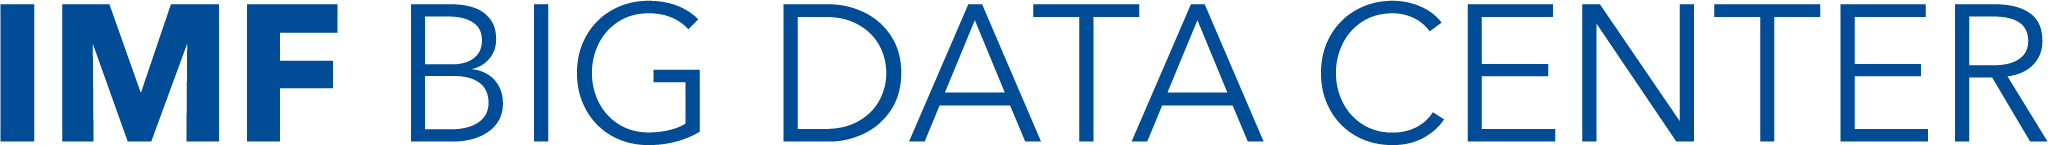

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/imfgit/imf_big_data_workshop_sti26/blob/main/notebooks/BDC_Sentiment_Analysis.ipynb)

# Sentiment Analysis




---

<br>**Contributors:** [Alberto Sanchez](asanchez3@imf.org)
<br> **Last update:** 2025-09-30 (Created: 2025-September)
<br> **Description:** Overview of the basic elements of Sentiment Analysis through examples. This notebook is organized into three main sections: (1) data access, dictionaries and scoring, (2) application on news, and (3) uses of HuggingFace transformers.
<br> **References:**

https://srdas.github.io/NLPBook/WebScraping_Dictionaries.html

https://srdas.github.io/NLPBook/News_Scraping.html

https://srdas.github.io/NLPBook/Tweets.html#using-the-nltk-package-to-conduct-sentiment-analysis-without-a-dictionary


## Fundamentals of textual sentiment analysis

<h3> <b> Problem statement </b>

Analyze sentiment of financial news

- Webscraping and data cleaning with Autrian National Bank website
- Sentiment models with Kaggle financial news dataset
- Try with AI and HuggingFace overview

### Set up

Import libraries and install necessary packages

In [3]:
# Install libraries
!pip install beautifulsoup4
!pip install pysentiment2 #import Harvard dictionary


In [2]:
import os
import re
import time
import random
import pandas as pd
import numpy as np
import nltk
import requests ## Reading in a URL
from nltk.corpus import PlaintextCorpusReader

Mount Google Drive

In [4]:
#If using Google Colab
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Set up data folder

<h3> ⏰ Don't forget to adjust the path </h3>

In [5]:
ROOT = '/content/drive/MyDrive/STI 2026/' #if using colab

workspace = "Day 4 - Text Analytics/"
data_folder = "Data"
folder = os.path.join(ROOT, workspace, data_folder)


In [6]:
os.path.exists(folder)

True

### Read datasets

Austrian National Bank: https://www.oenb.at/en/



<h3><b> ⚠  IMPORTANT: Use an appropriate website resource that allows web scraping. Always ensure that the terms of use of the source you plan to use allows your use case.

The Austrian Central Bank website has a fairly open reuse policy and do not include any scraping prohibition.

Copyright notice and disclaimer - Oesterreichische Nationalbank (OeNB): https://www.oenb.at/en/Services/copyright-notice-and-disclaimer.html

<!DOCTYPE html>
<!--[if lt IE 7 ]><html class="ie ie6" lang="de"> <![endif]-->
<!--[if IE 7 ]><html class="ie ie7" lang="de"> <![endif]-->
<!--[if IE 8 ]><html class="ie ie8" lang="de"> <![endif]-->
<!--[if IE 9 ]><html class="ie9" lang="de"> <![endif]-->
<!--[if (gt IE 9)|!(IE)]><!--><html lang="de"> <!--<![endif]-->
<head>

<script>
  var contextPath='';
</script>

  <!-- JS - Consentmanager - must be the FIRST .js (so it will block trackers like Google Analytics until user's consent)
  ================================================== -->
  <script>
    window.cmp_setlang = 'DE';
  </script>
  <script type="text/javascript" data-cmp-ab="1" src="https://cdn.consentmanager.net/delivery/autoblocking/362bc64b8804.js" data-cmp-host="c.delivery.consentmanager.net" data-cmp-cdn="cdn.consentmanager.net" data-cmp-codesrc="1"></script>


<!-- Basic Page Needs
================================================== -->
<meta charset="utf-8">
<title>Financial Stability Report 49 - Oesterreichische 
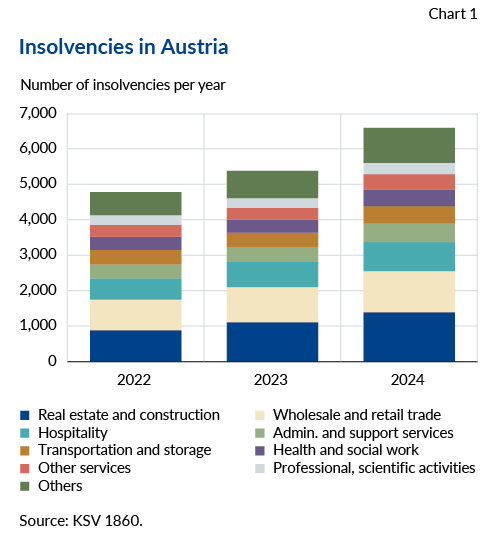
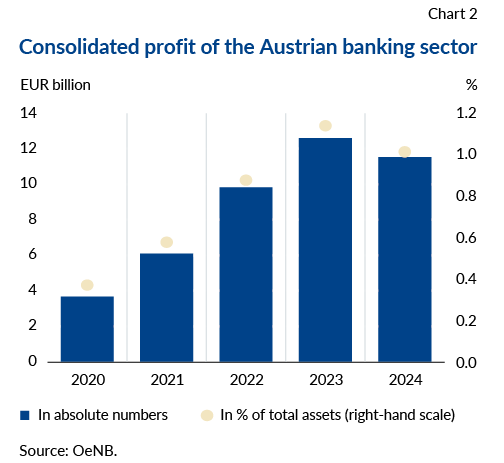
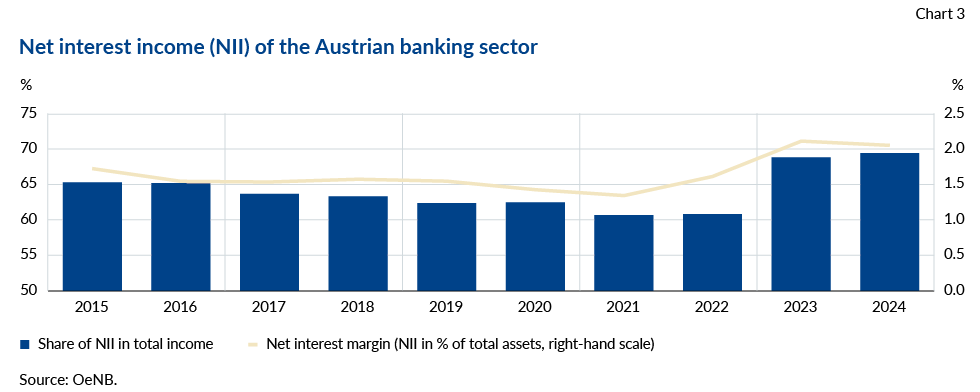
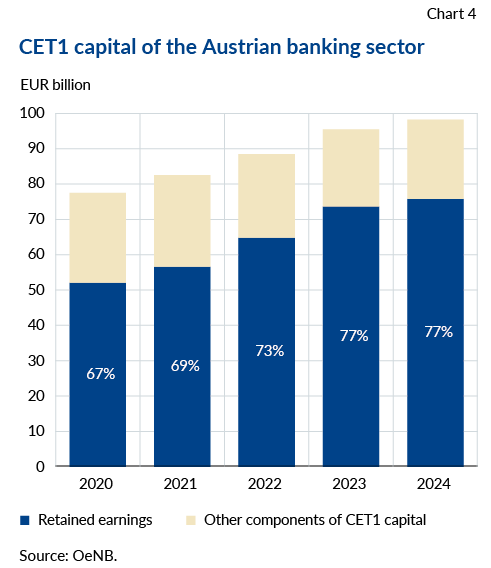
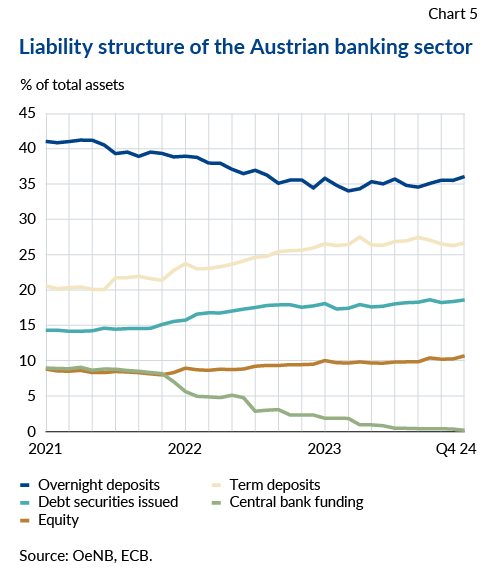
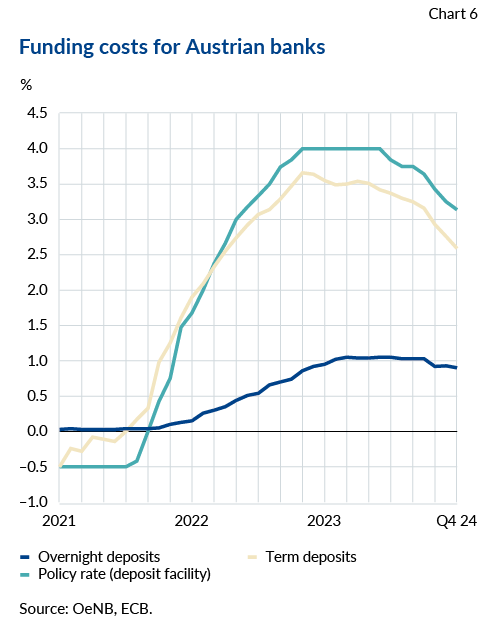
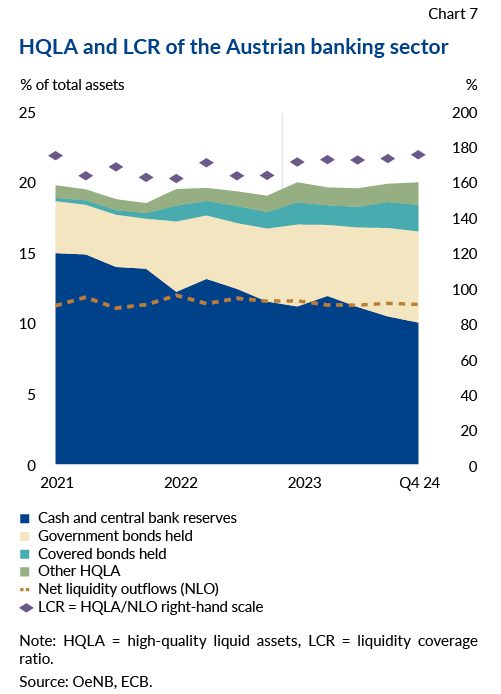
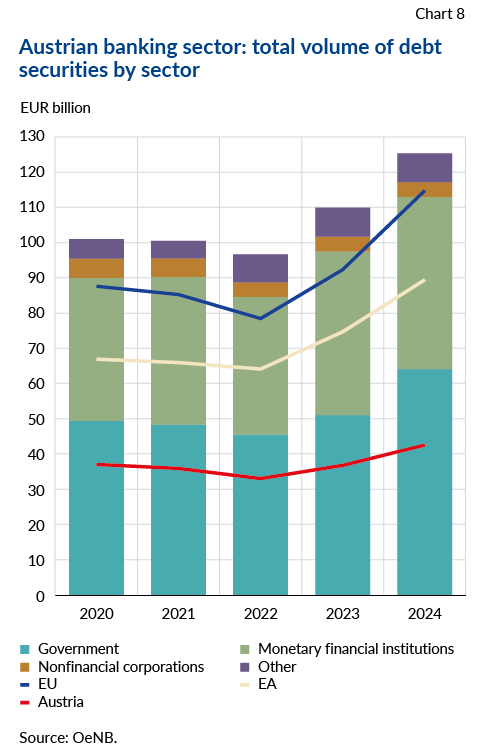
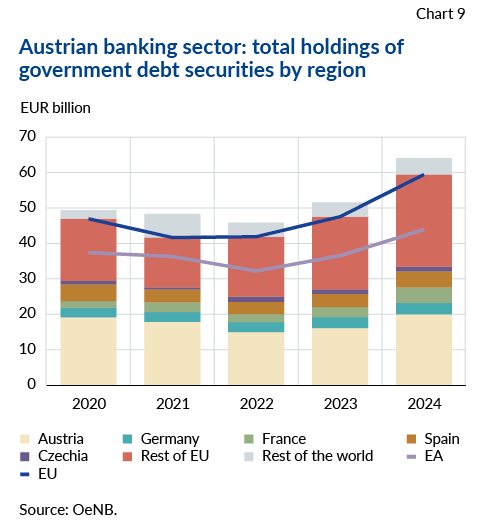
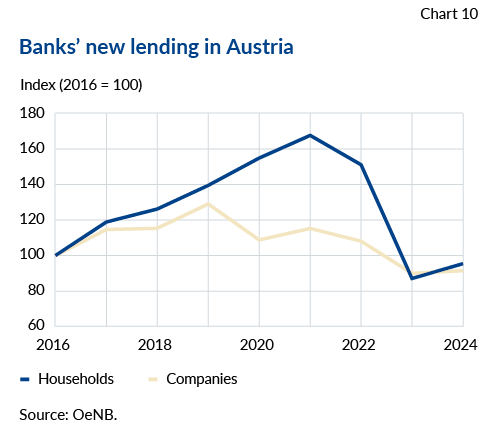
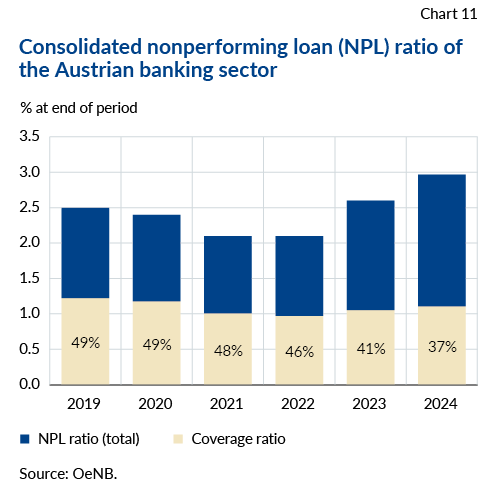
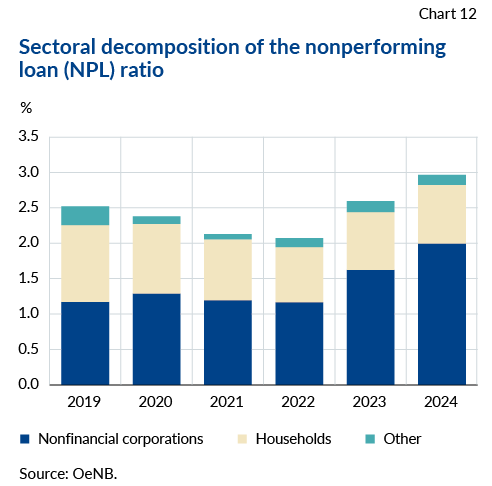
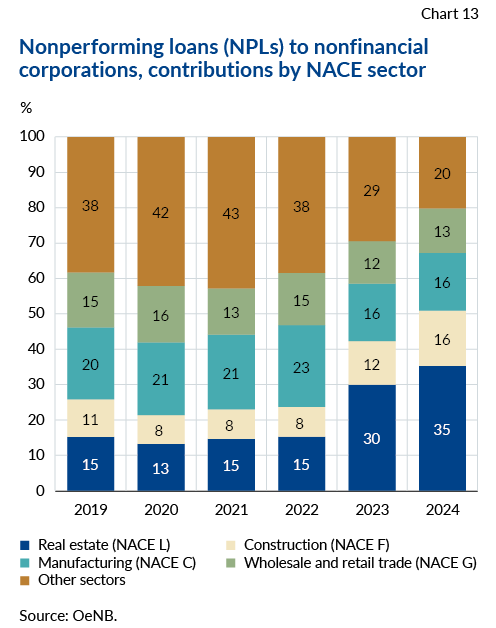
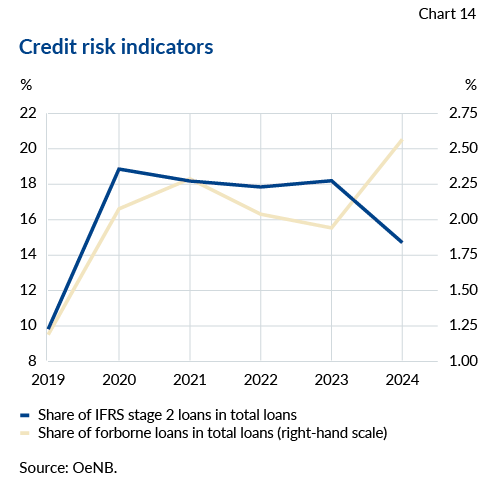
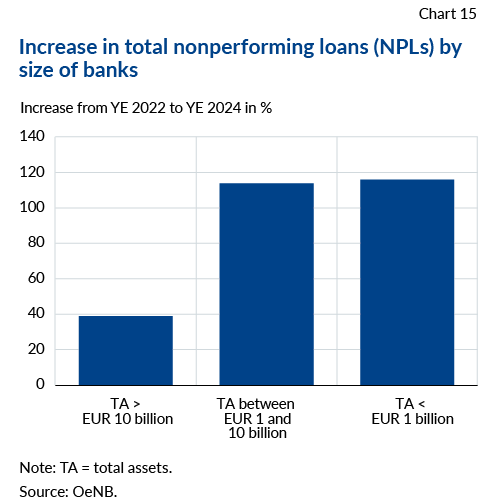
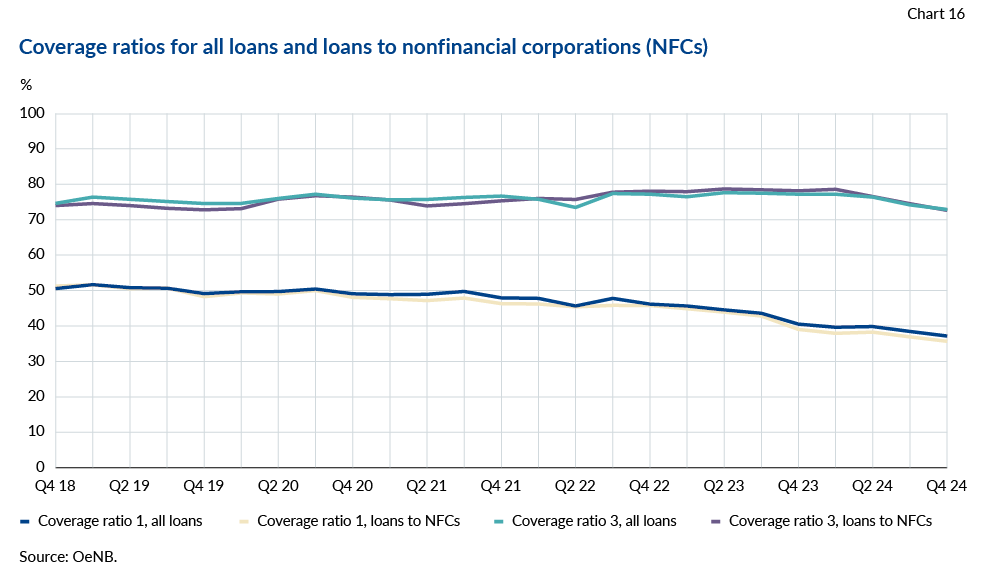
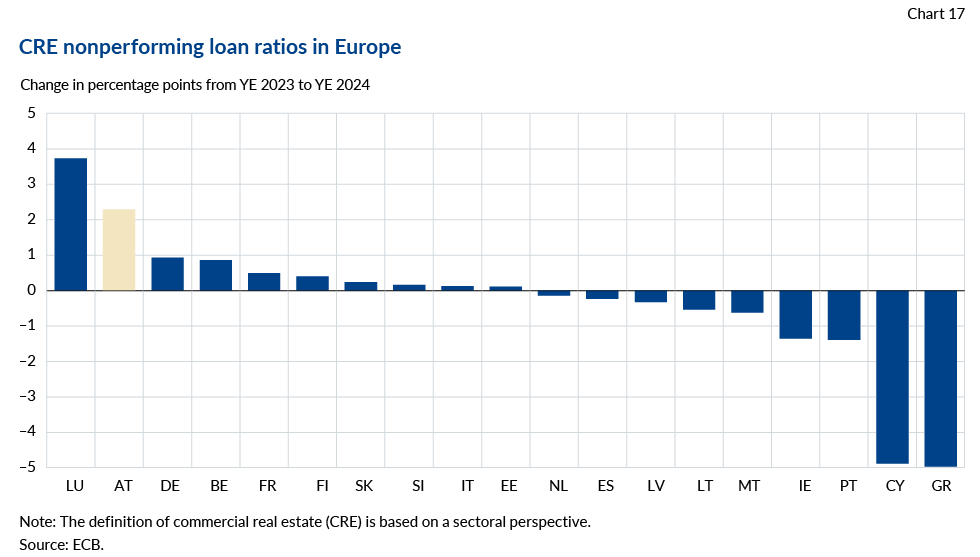
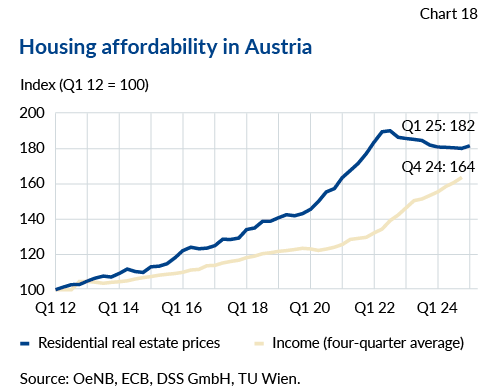
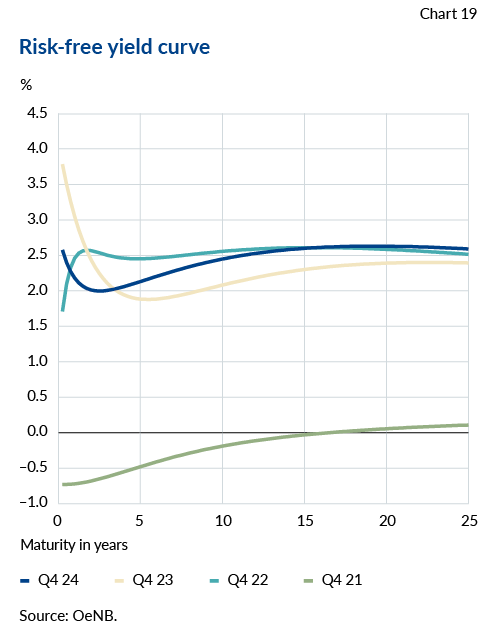
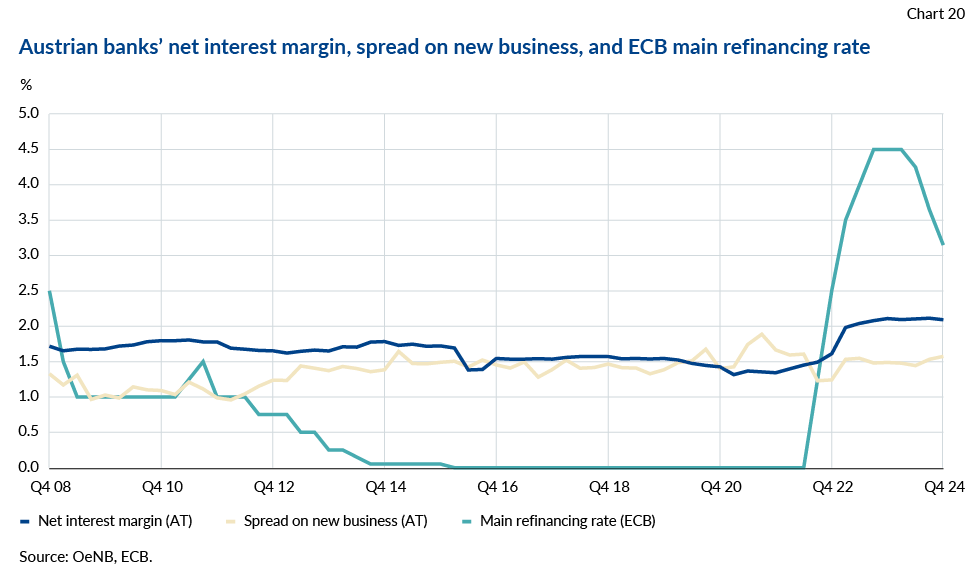
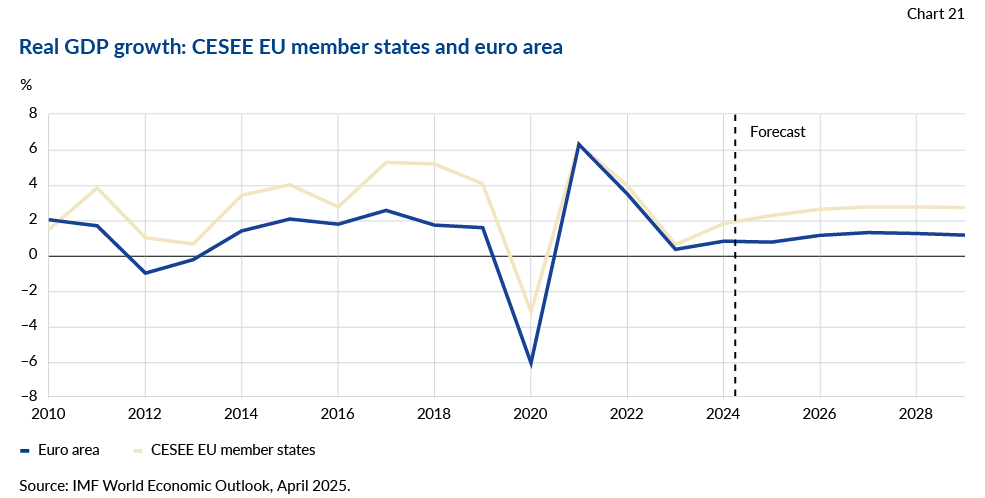
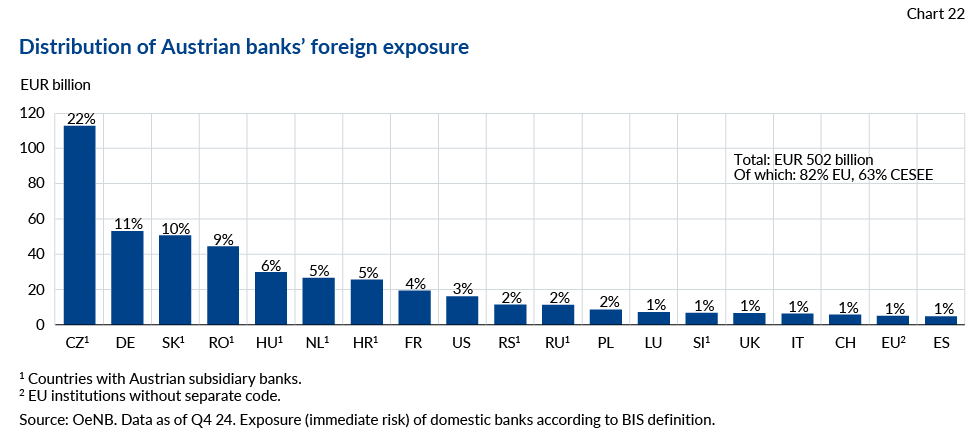
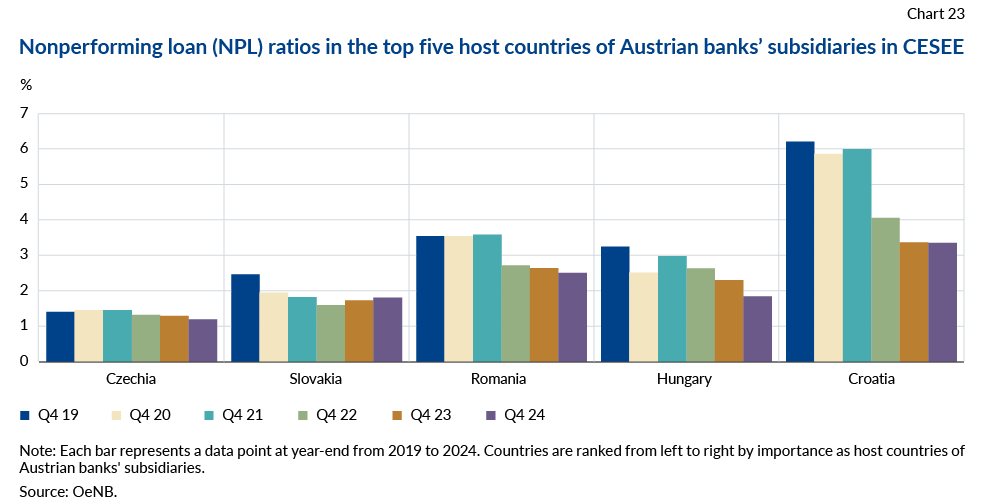
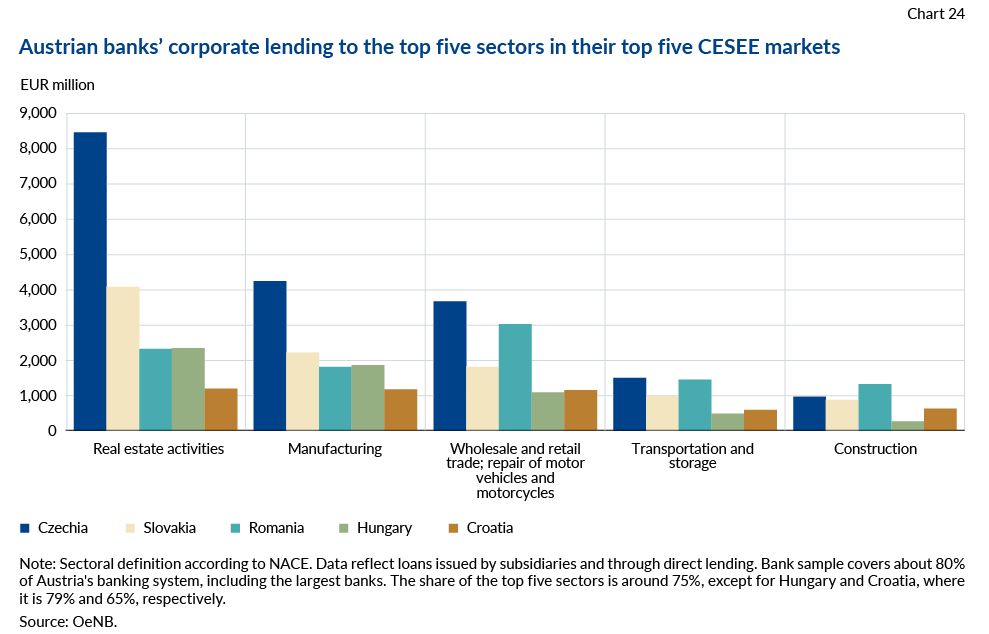
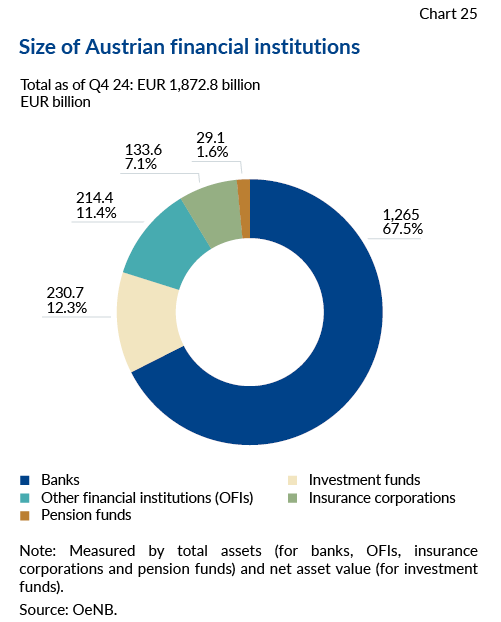
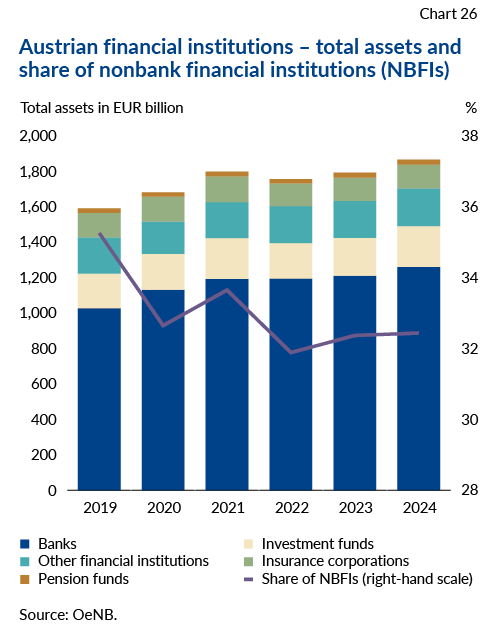
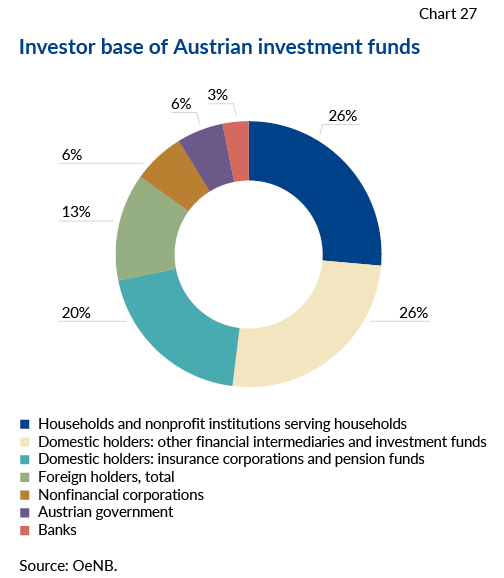
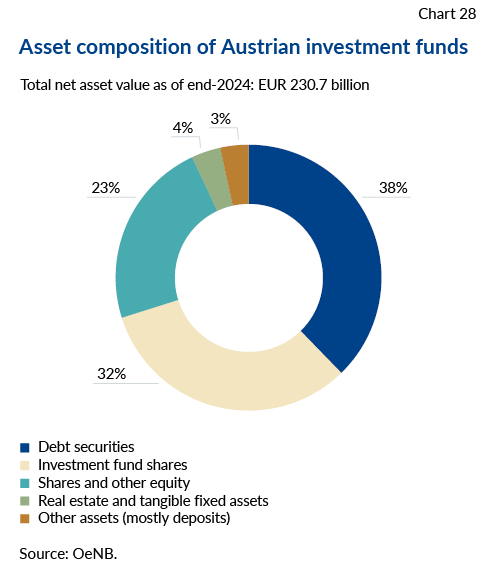
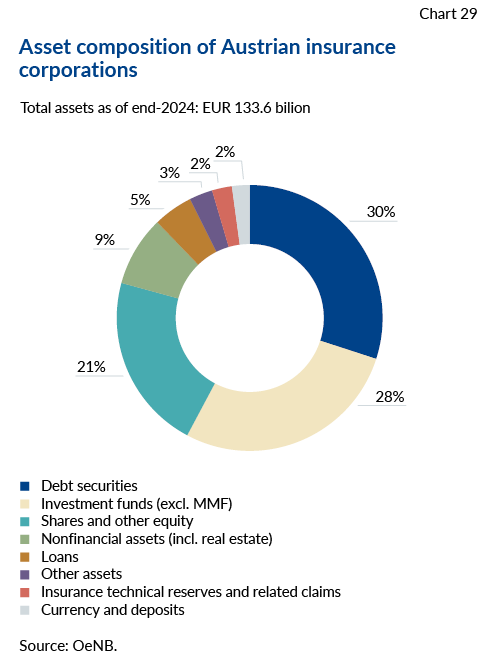
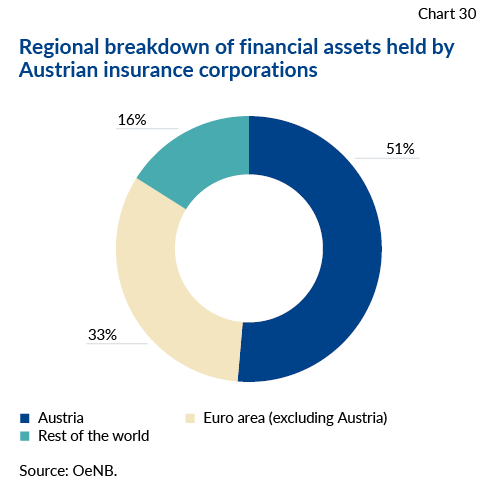

In [7]:
url = 'https://www.oenb.at/Publikationen/Finanzmarkt/Finanzmarktstabilitaetsbericht/2025/financial-stability-report-49/html-version.html'
f = requests.get(url)
text = f.text
print(text)
f.close()

### Clean up data

Use BeautifulSoup to clean up the html

<!DOCTYPE html>
<!--[if lt IE 7 ]><html class="ie ie6" lang="de"> <![endif]-->
<!--[if IE 7 ]><html class="ie ie7" lang="de"> <![endif]-->
<!--[if IE 8 ]><html class="ie ie8" lang="de"> <![endif]-->
<!--[if IE 9 ]><html class="ie9" lang="de"> <![endif]-->
<!--[if (gt IE 9)|!(IE)]><!-->
<html lang="de">
 <!--<![endif]-->
 <head>
  <script>
   var contextPath='';
  </script>
  <!-- JS - Consentmanager - must be the FIRST .js (so it will block trackers like Google Analytics until user's consent)
  ================================================== -->
  <script>
   window.cmp_setlang = 'DE';
  </script>
  <script data-cmp-ab="1" data-cmp-cdn="cdn.consentmanager.net" data-cmp-codesrc="1" data-cmp-host="c.delivery.consentmanager.net" src="https://cdn.consentmanager.net/delivery/autoblocking/362bc64b8804.js" type="text/javascript">
  </script>
  <!-- Basic Page Needs
================================================== -->
  <meta charset="utf-8"/>
  <title>
   Financial Stability Report 49 - 
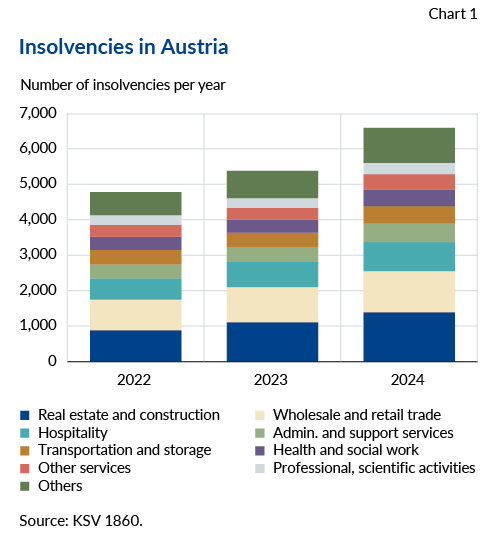
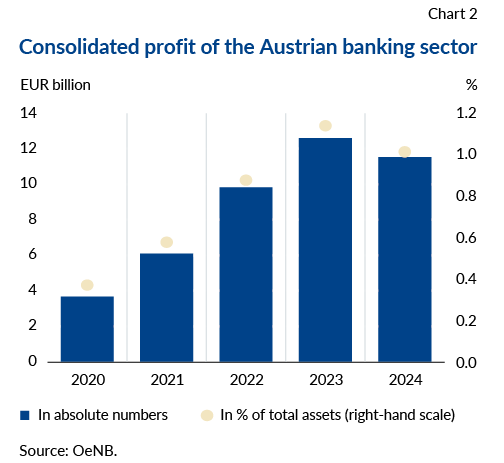
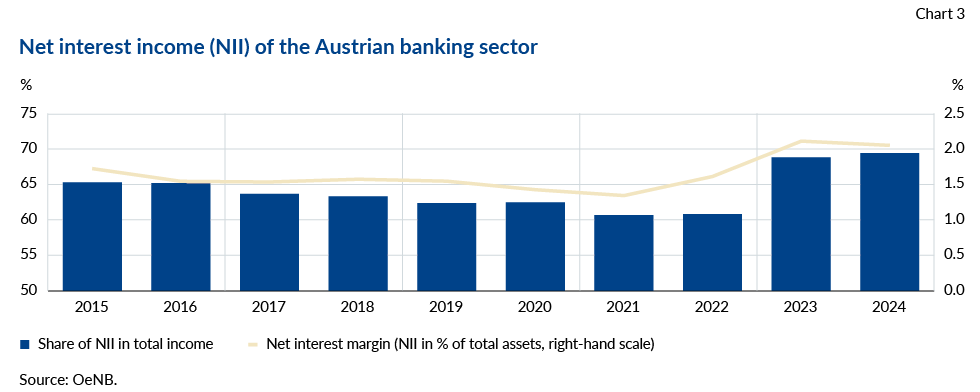
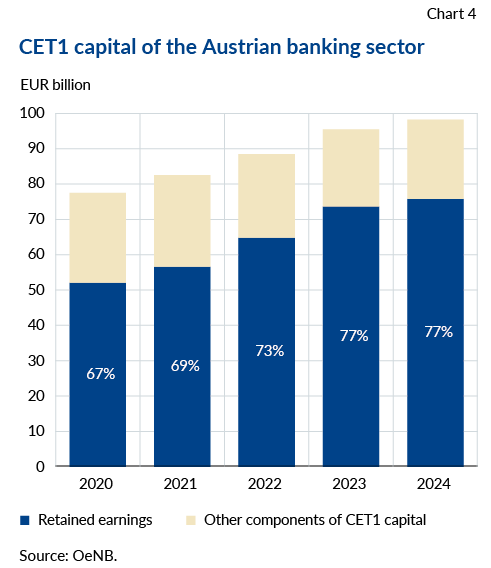
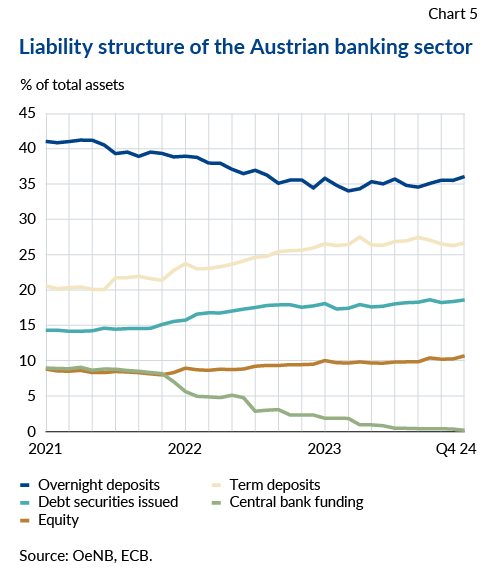
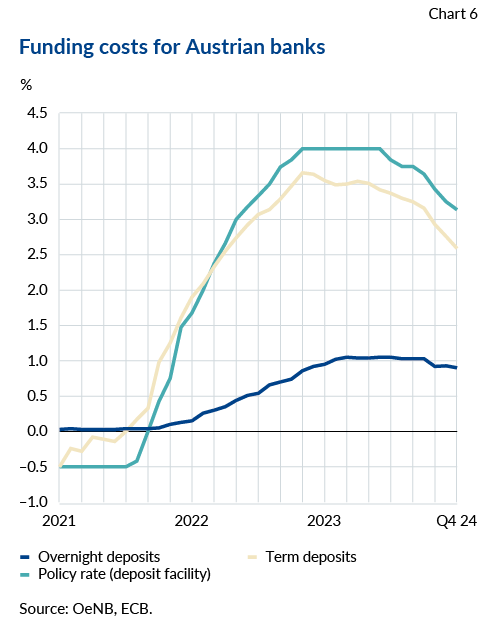
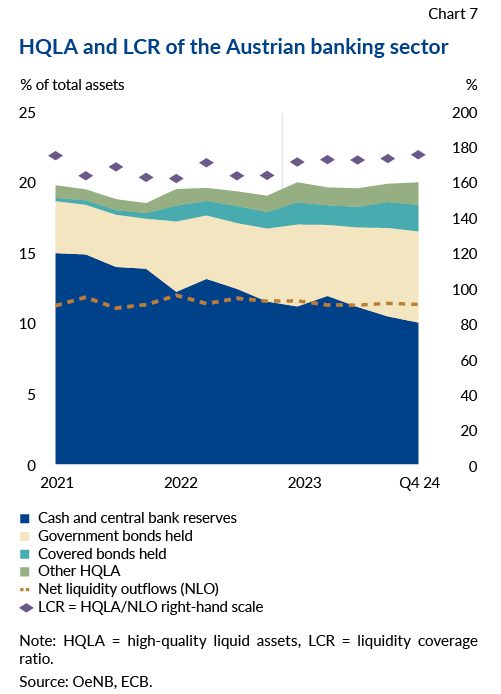
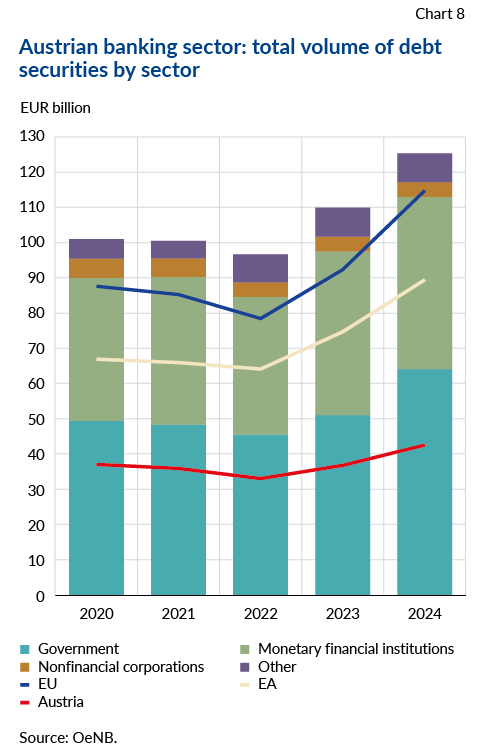
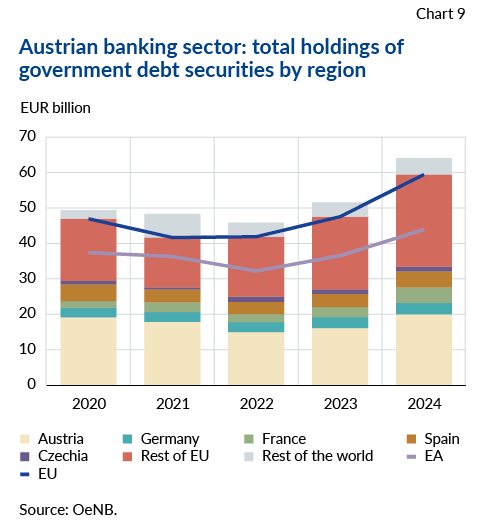
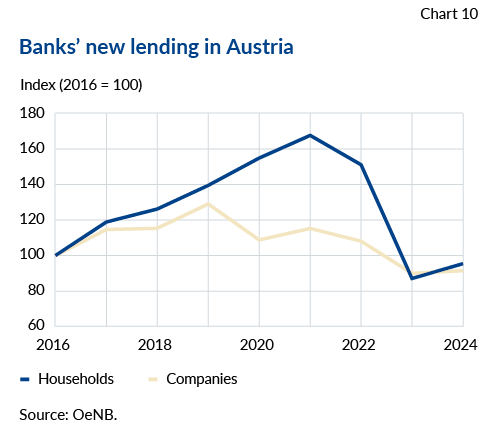
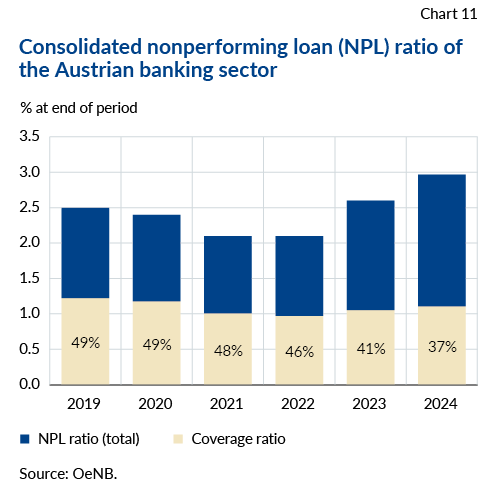
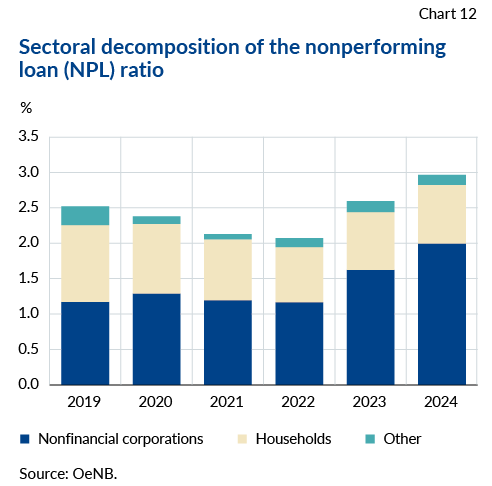
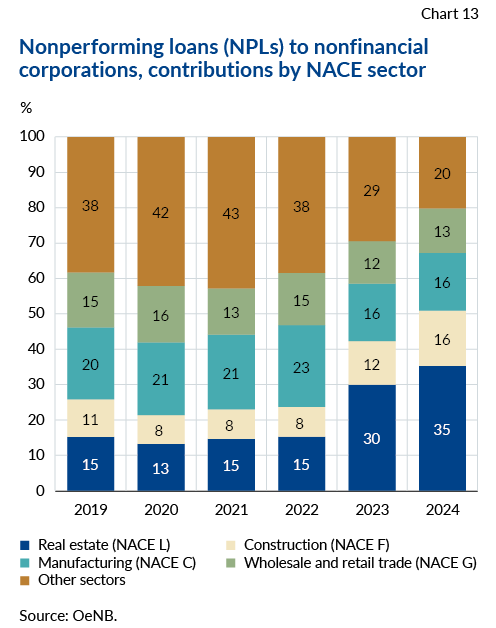
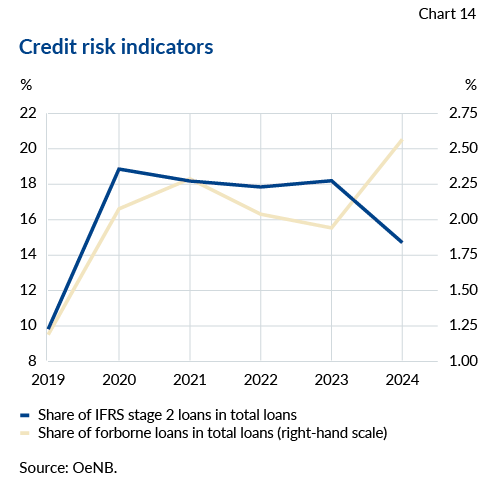
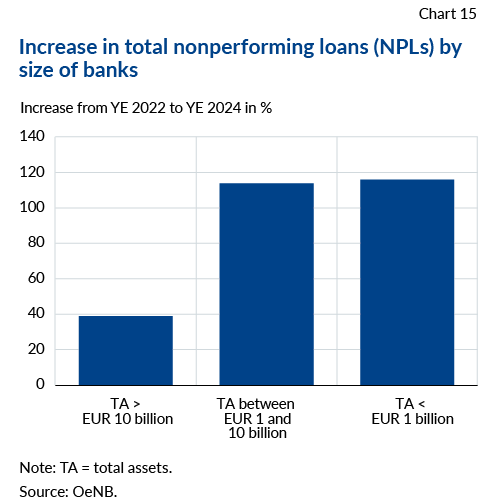
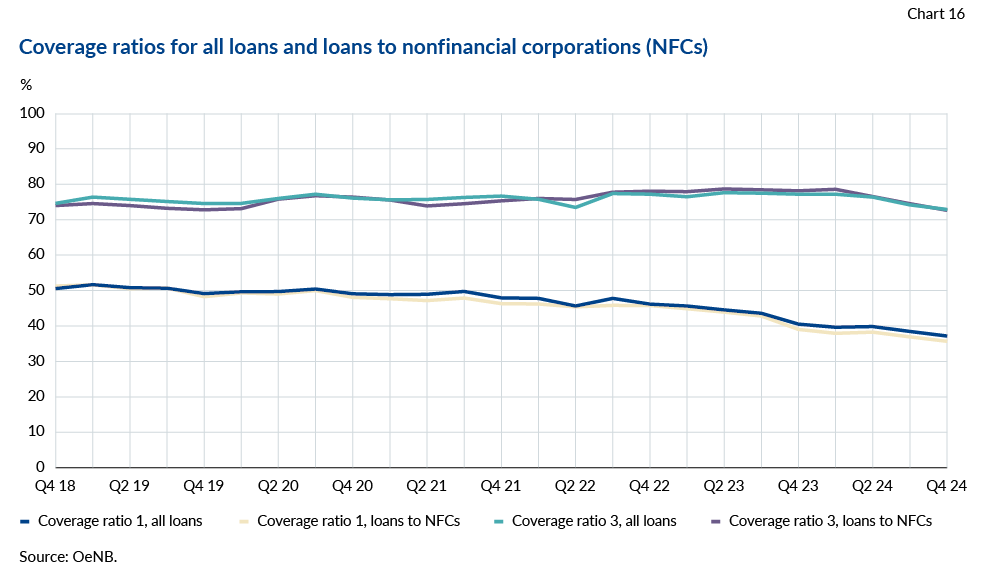
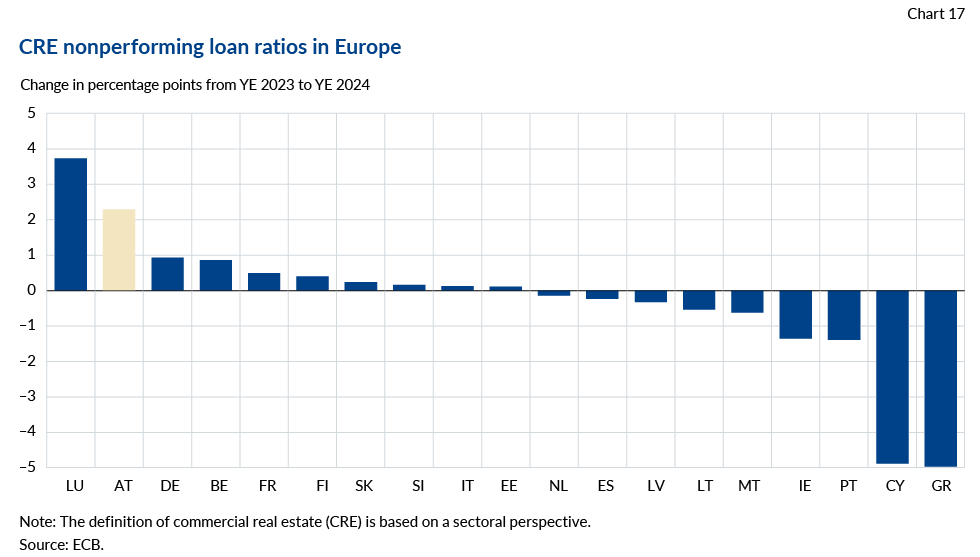
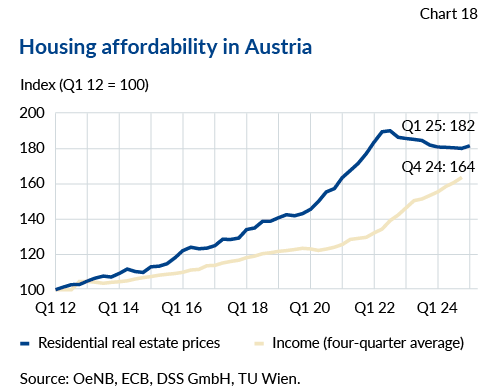
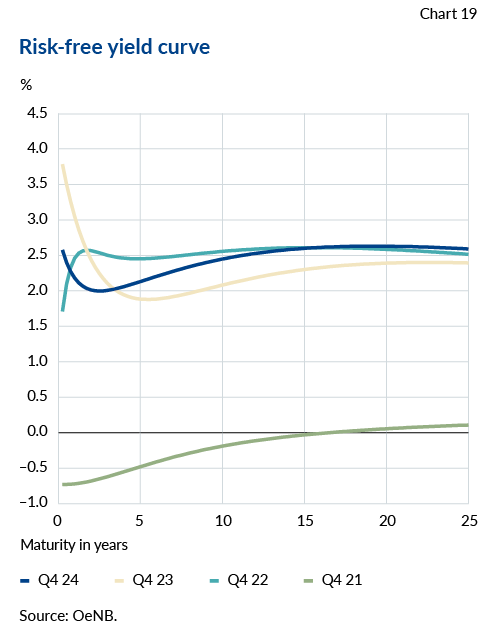
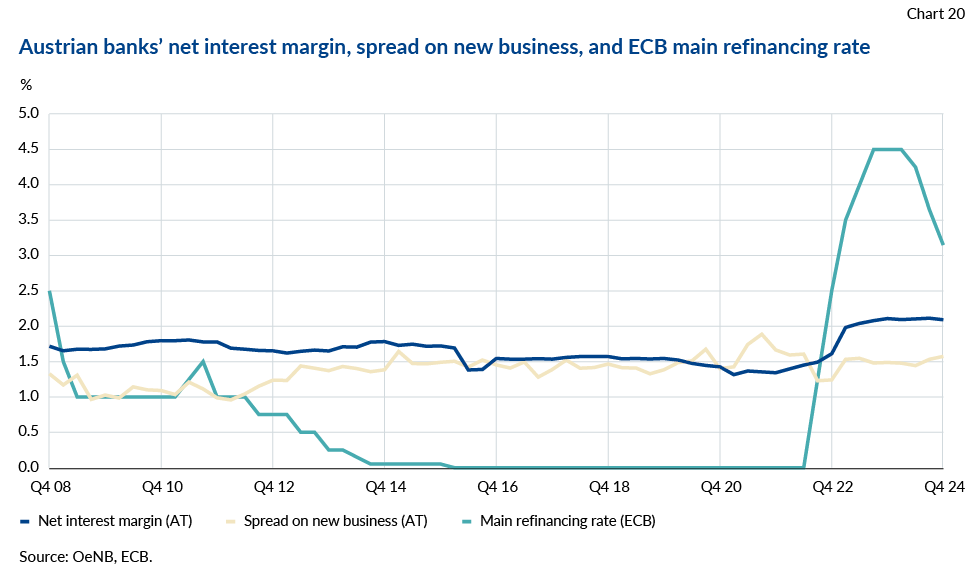
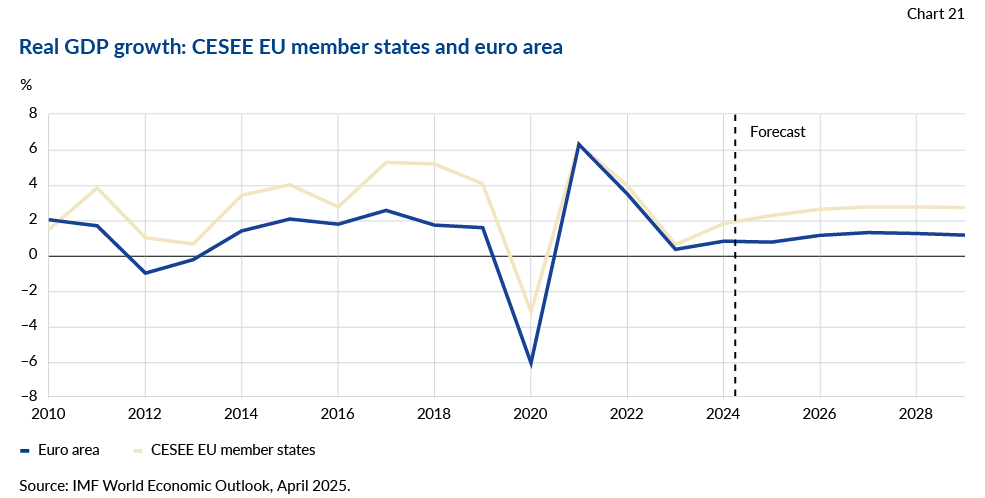
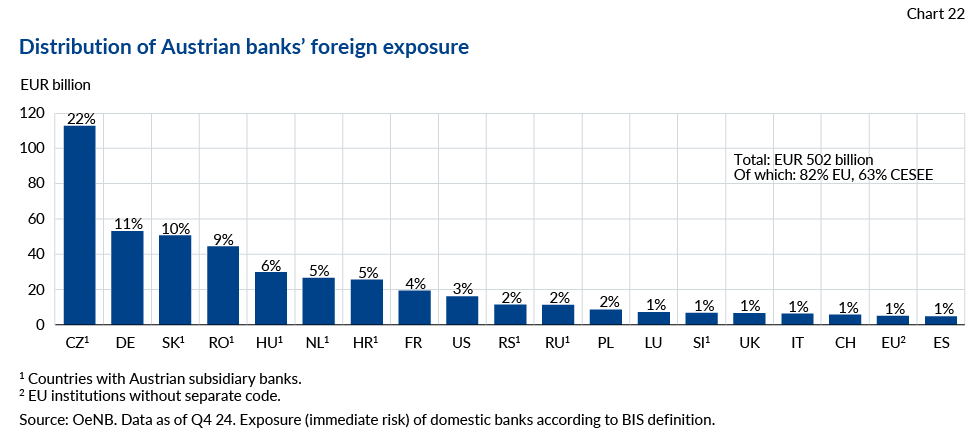
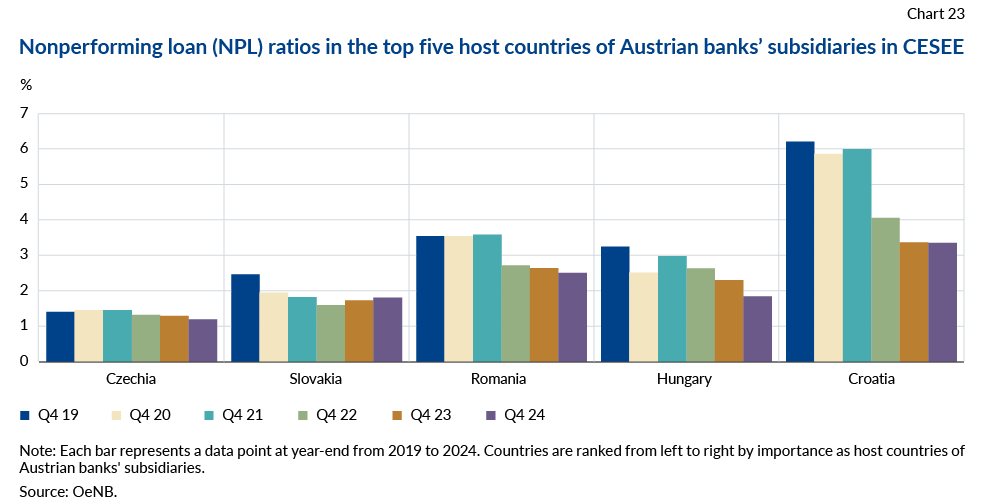
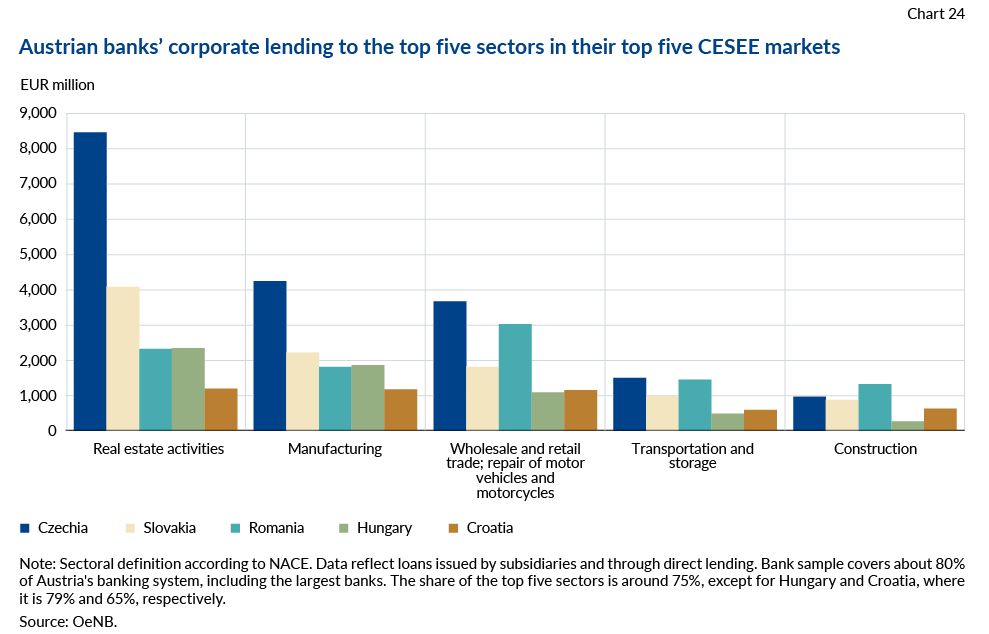
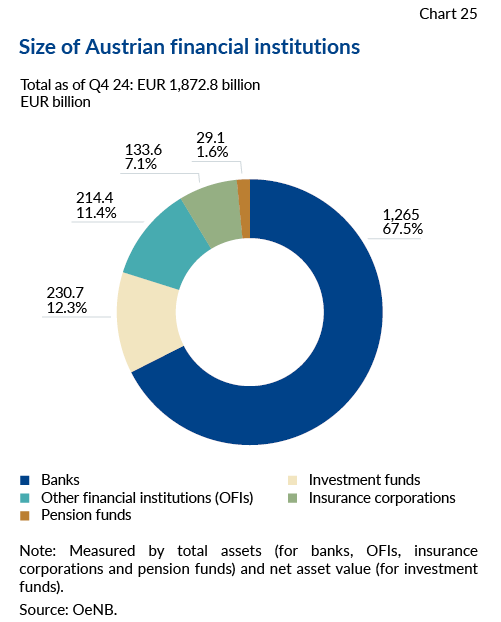
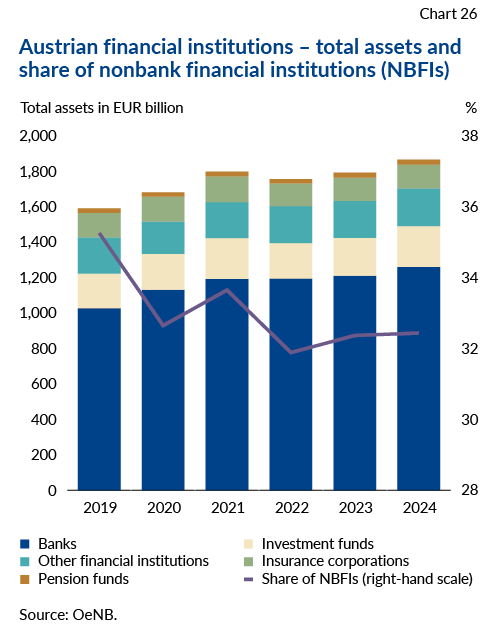
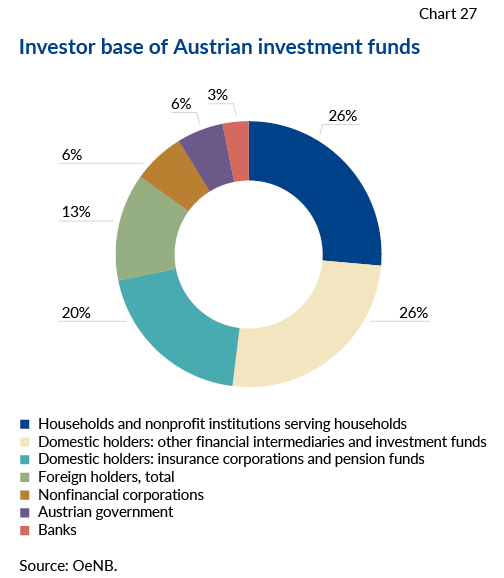
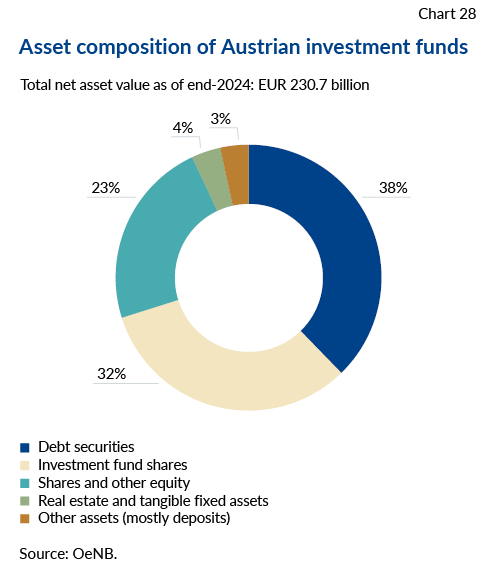
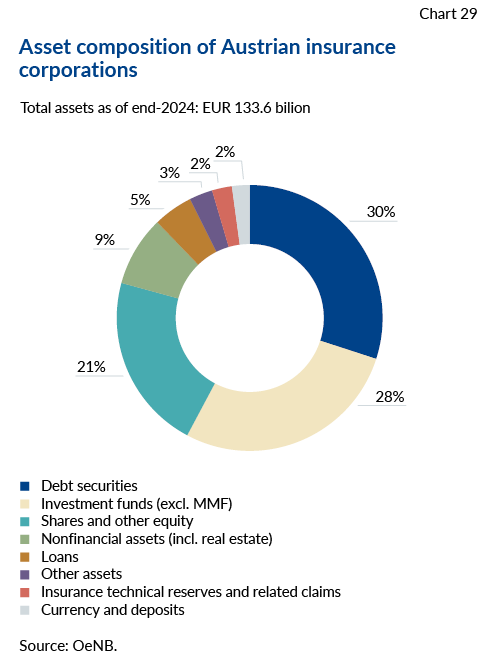
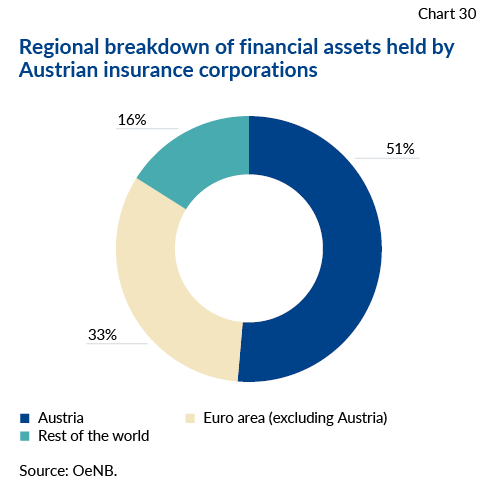

In [8]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(text, 'html.parser')
print(soup.prettify())

Explore the content

<title>Financial Stability Report 49 - Oesterreichische Nationalbank (OeNB)</title>
1
<class 'bs4.element.Tag'>
<a href="#navigation">Zur Navigation</a>
<article>
<h1>Financial Stability Report 49</h1>
<div>
<h2 id="management-summary1">
  Management summary
  <sup>
<a href="#footnote-000-0" id="footnote-000-backlink-0">
    1
   </a>
</sup>
</h2>
<div class="textblock textblock--lead">
<p id="paragraph-0000">
   Despite mounting domestic economic challenges, Austria’s banking sector delivered another year of ­robust profitability in 2024, underpinned by strong net interest income. Retained earnings helped to strengthen capital, enhancing the sector’s resilience in an environment marked by heightened geopolitical and trade-related uncertainty.
  </p>
</div>
<p id="paragraph-0001">
  After two consecutive years of economic contraction, the OeNB expects only a very moderate recovery of the Austrian economy in 2025 (+0.2%). This weak recovery after the most prolonged downturn since 1945 i
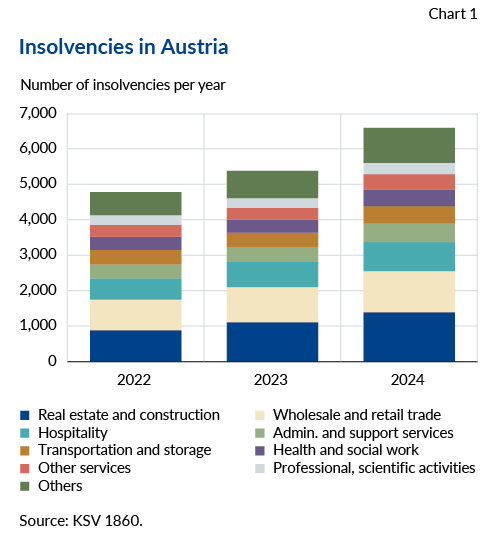
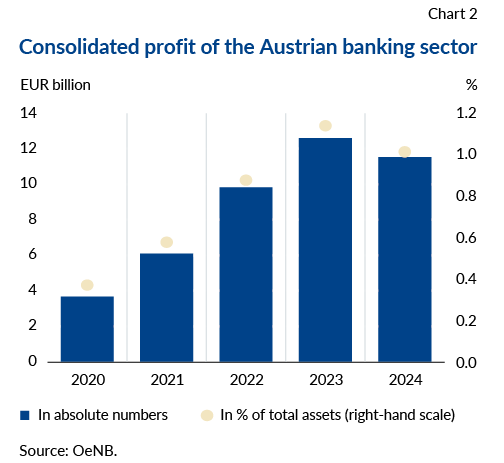
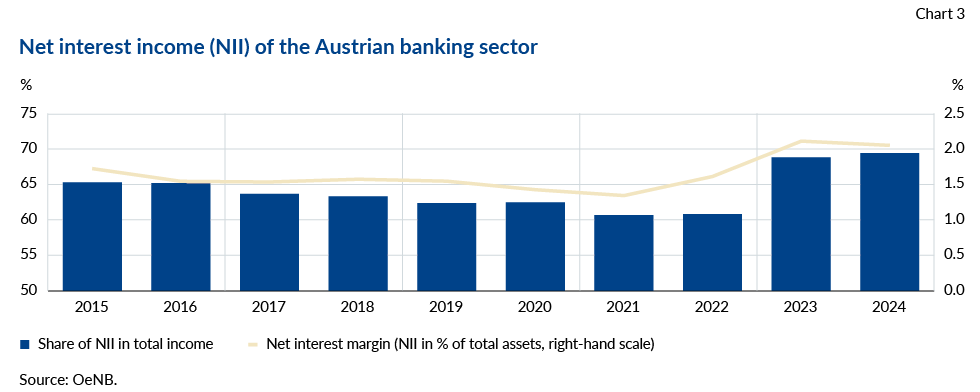
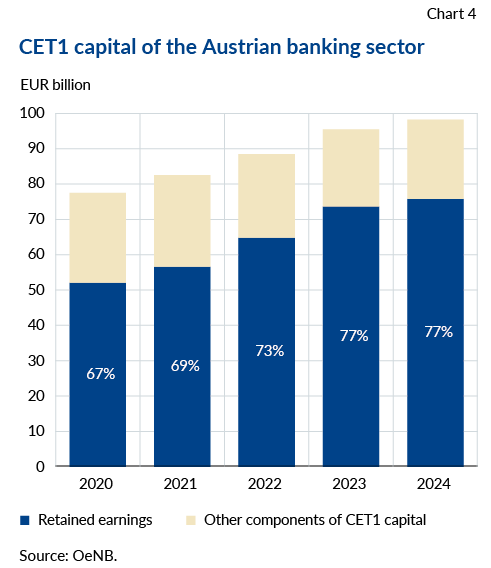
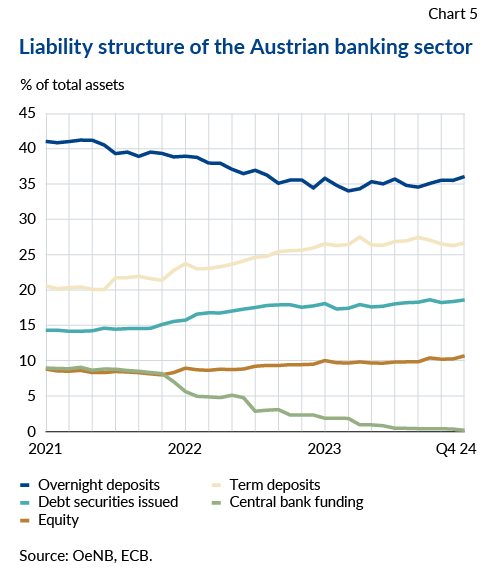
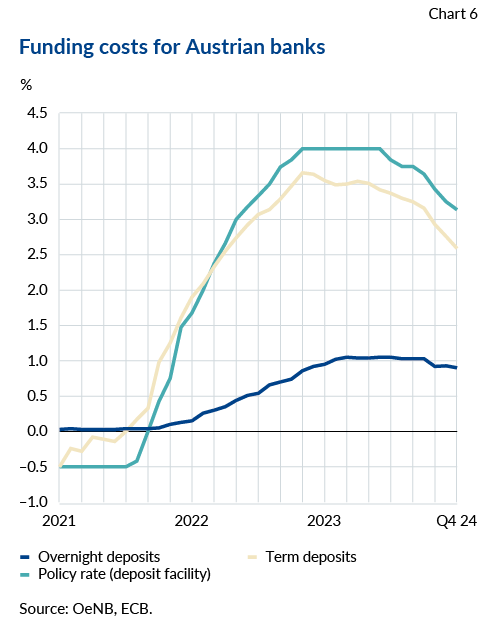
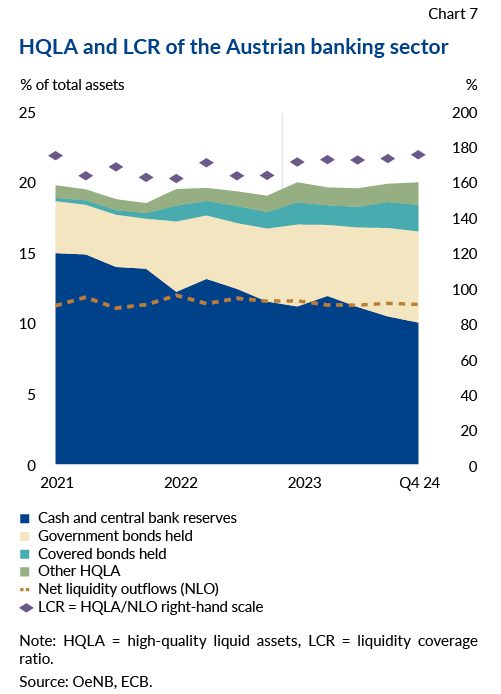
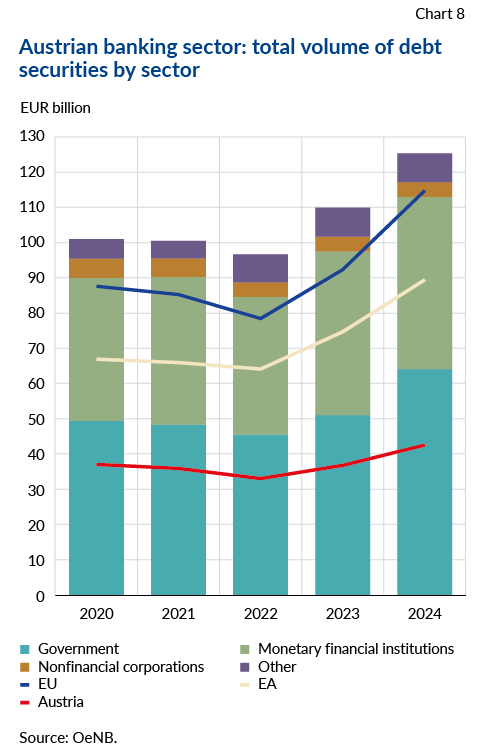
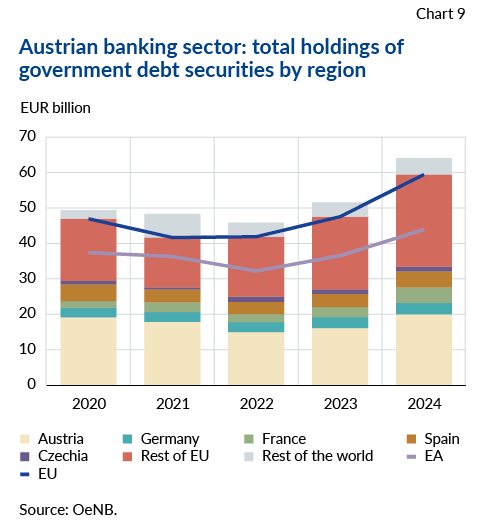
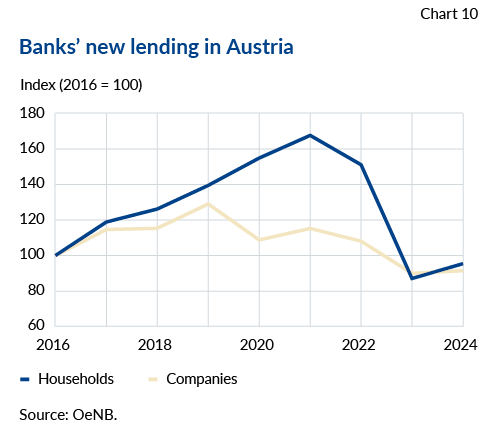
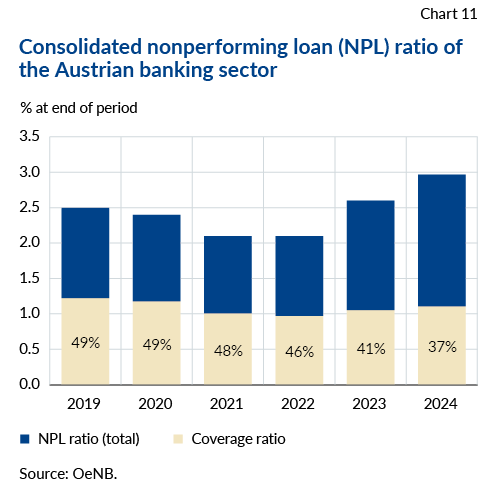
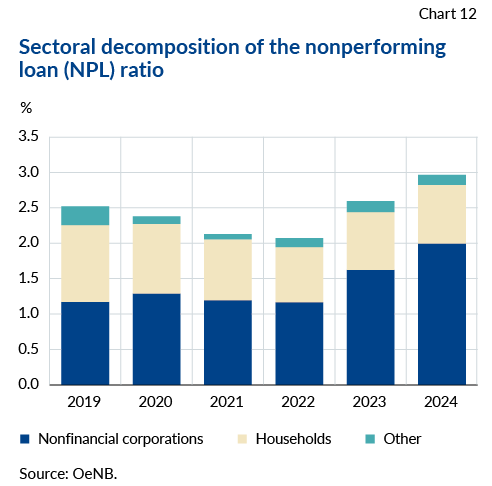
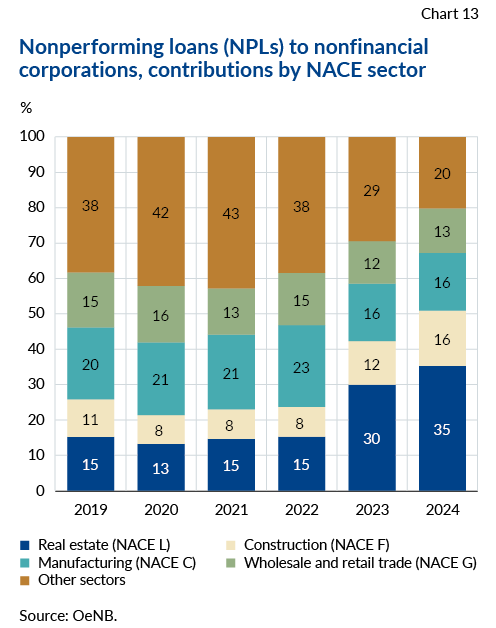
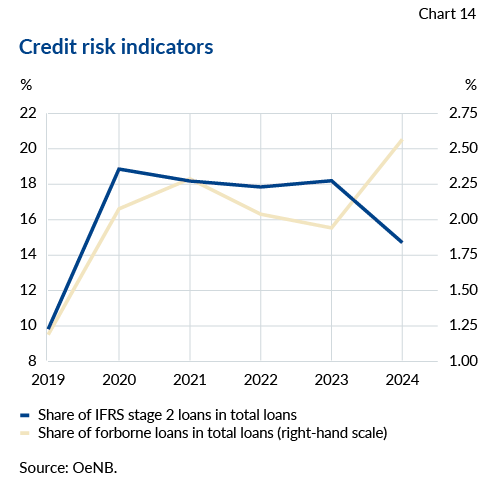
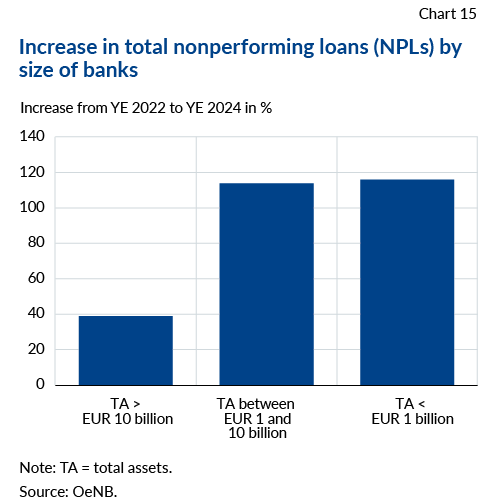
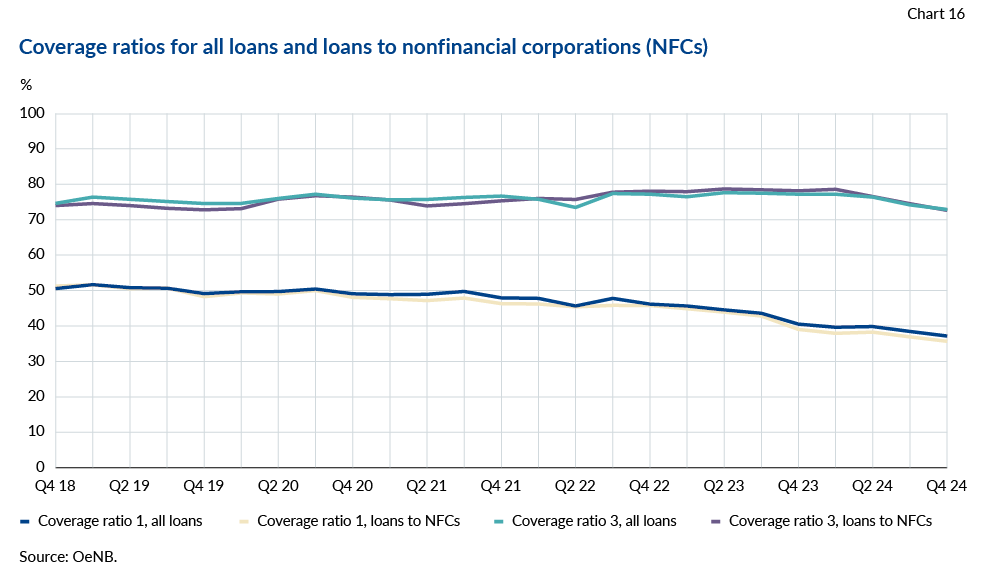
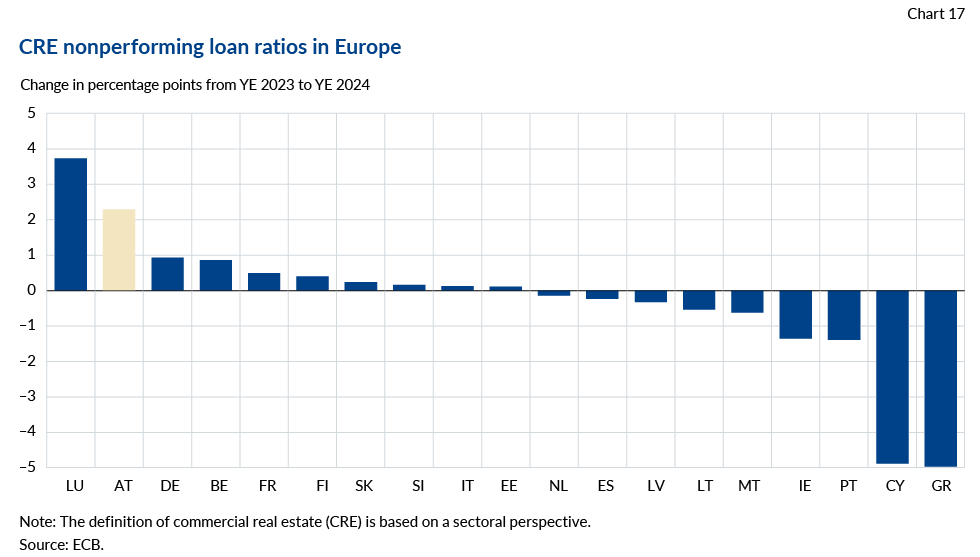
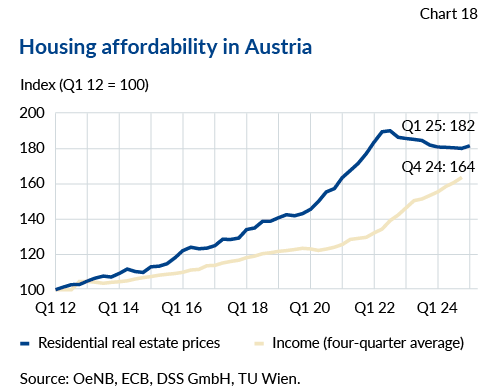
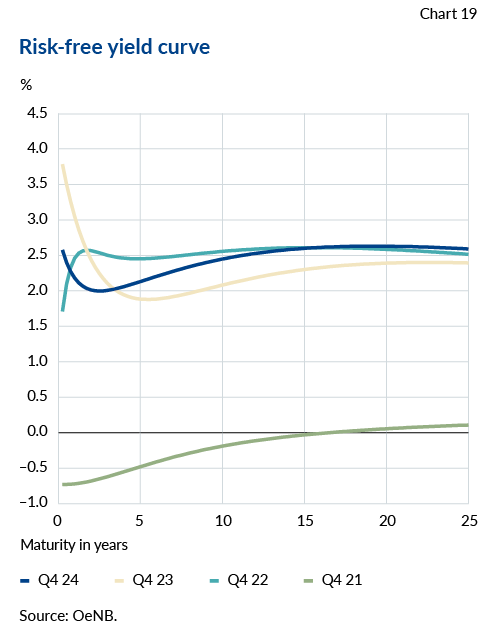
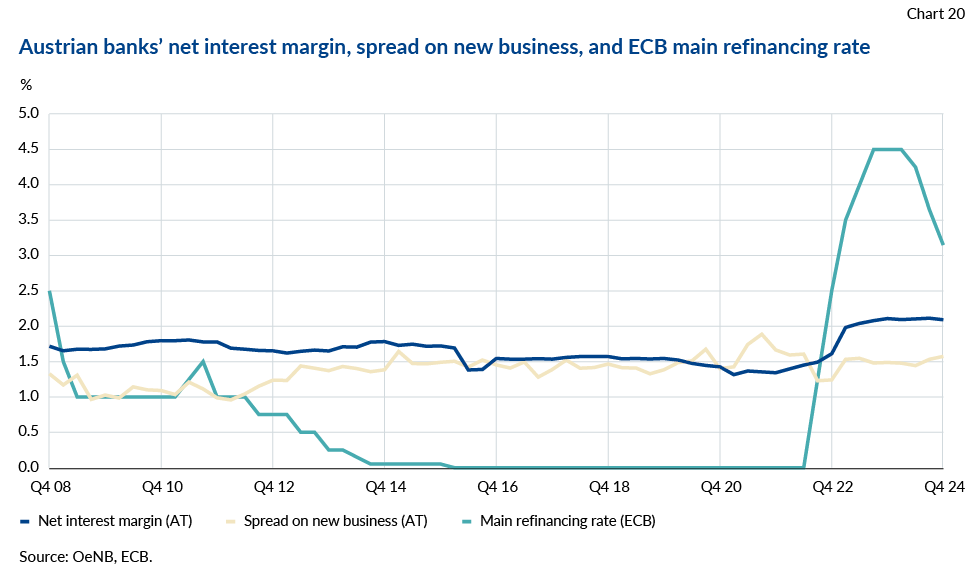
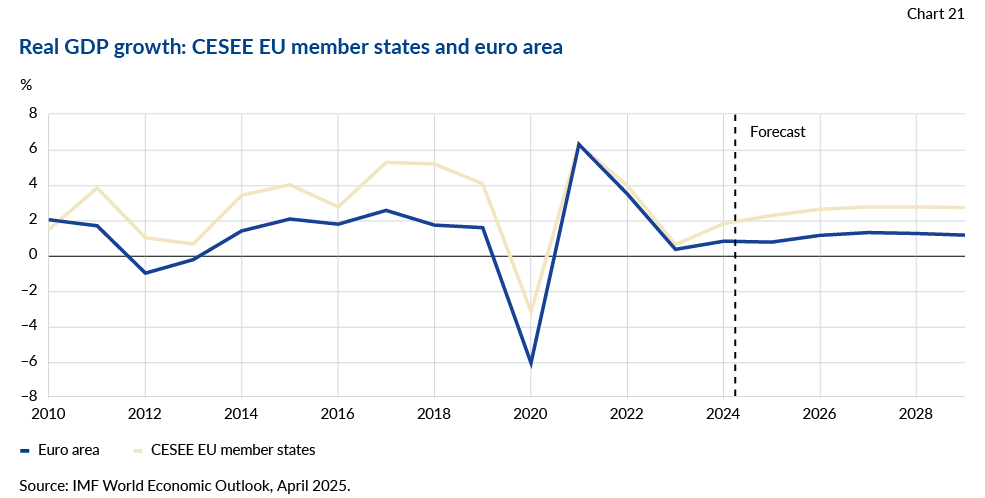
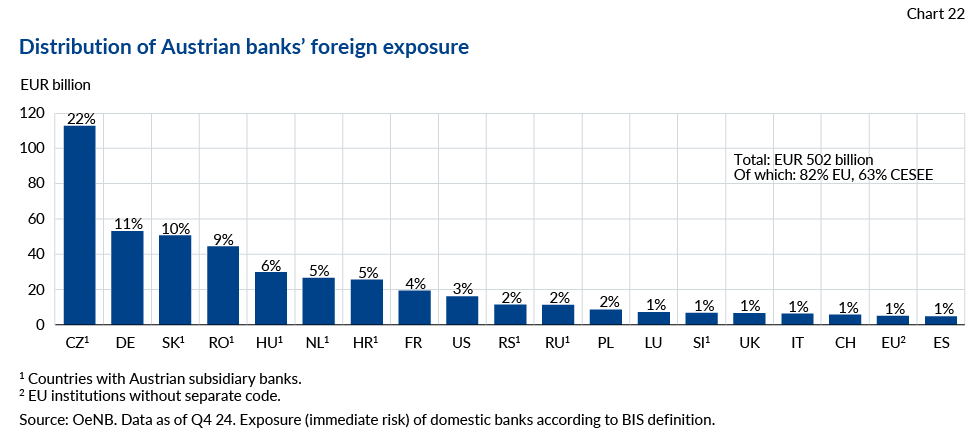
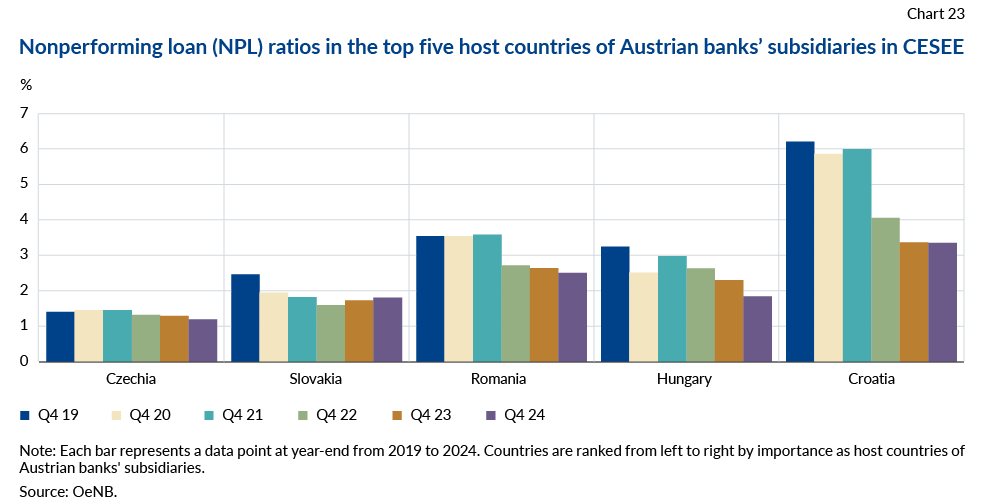
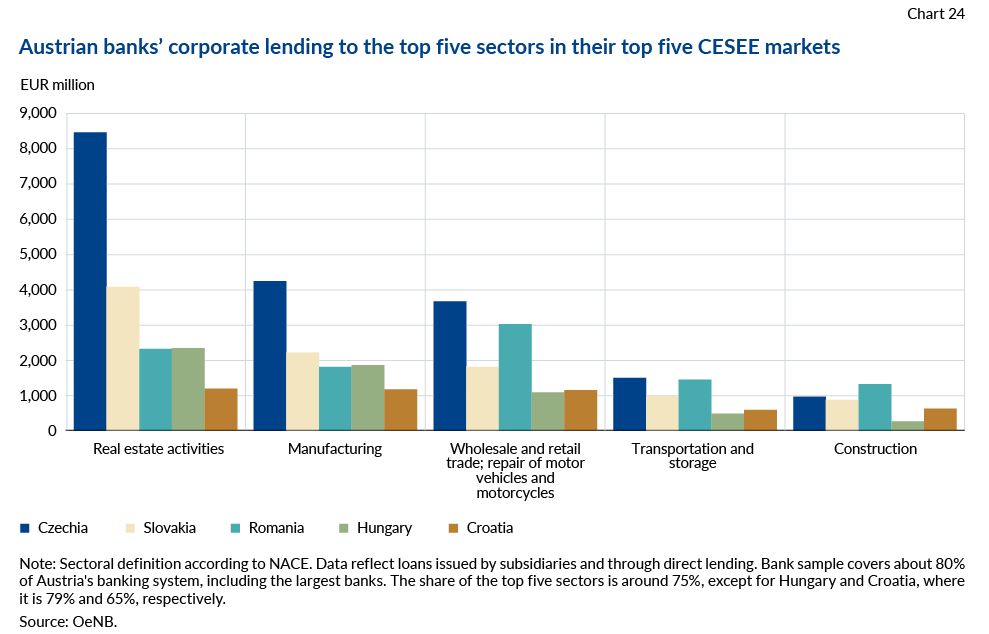
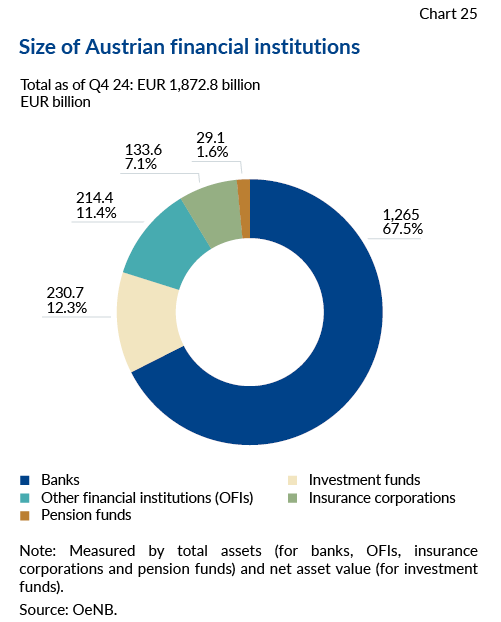
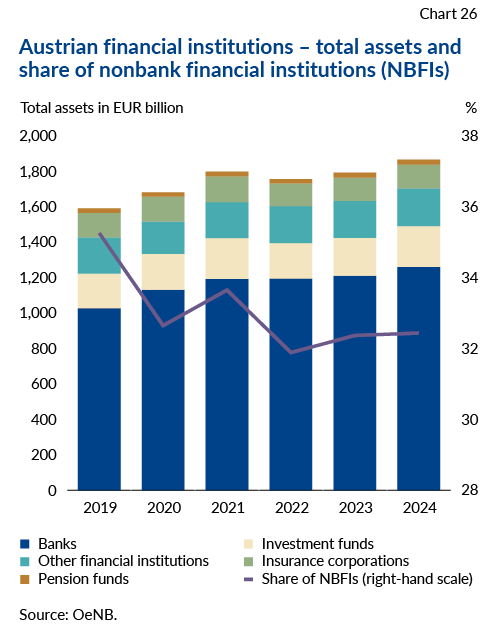
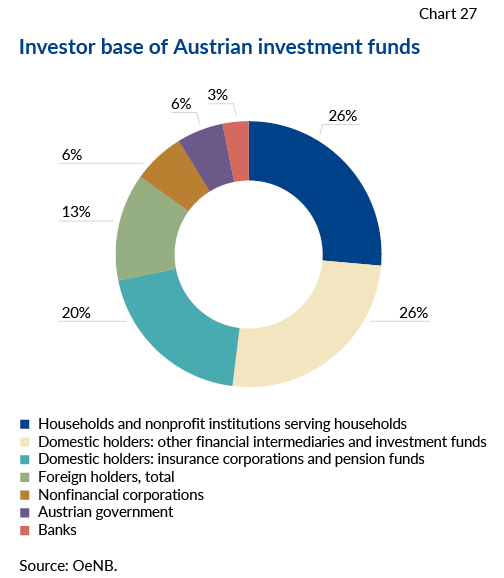
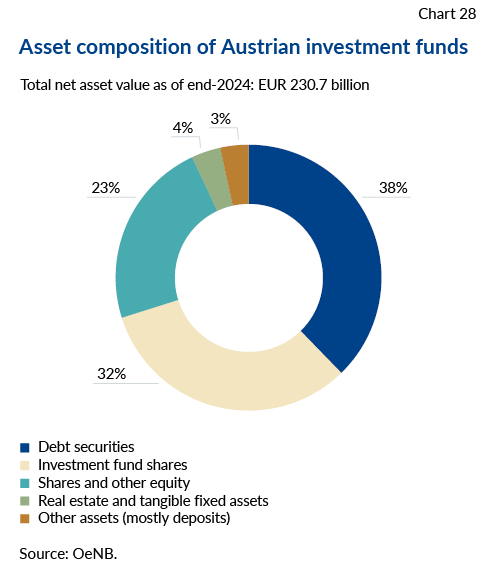
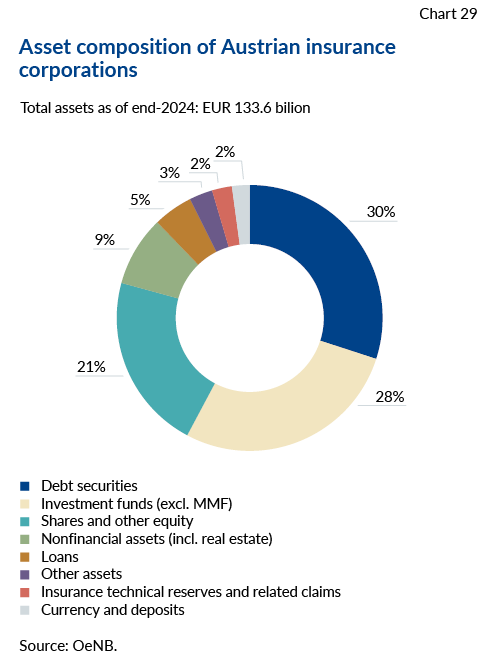
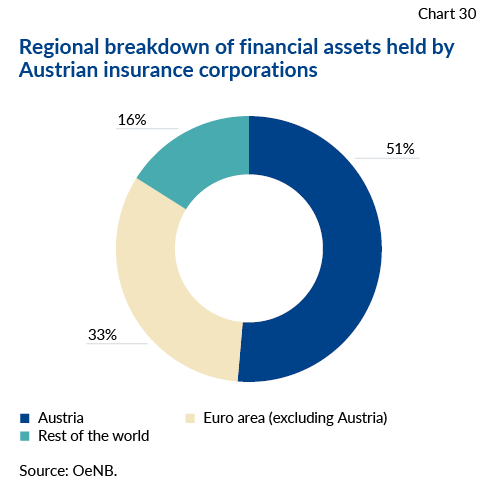

In [9]:
print(soup.title)
print(len(soup.p))
print(type(soup.p))
print(soup.a)
print(soup.article)

Extract paragraphs

In [10]:
paragraphs = soup.find_all('p')

if paragraphs:
    print("Content from all paragraph tags:")
    for i, p in enumerate(paragraphs):
        print(f"Paragraph {i+1}: {p.get_text(strip=True)}")
else:
    print("Could not find any paragraph tags.")

Content from all paragraph tags:
Paragraph 1: Zur Navigation
Paragraph 2: Zum Inhalt
Paragraph 3: Despite mounting domestic economic challenges, Austria’s banking sector delivered another year of ­robust profitability in 2024, underpinned by strong net interest income. Retained earnings helped to strengthen capital, enhancing the sector’s resilience in an environment marked by heightened geopolitical and trade-related uncertainty.
Paragraph 4: After two consecutive years of economic contraction, the OeNB expects only a very moderate recovery of the Austrian economy in 2025 (+0.2%). This weak recovery after the most prolonged downturn since 1945 is mainly due to Austria’s weak price competitiveness in both the industrial and service sectors ­following the surge in inflation and subsequent wage increases above the euro area average. While industrial production was surprisingly strong around the turn of the year 2025, the introduction of US tariffs on goods from European and many other co

Save as string

In [11]:
# Assuming 'paragraphs' variable contains the list of paragraph tags from the previous cell
paragraph_text = ""
if paragraphs:
    for p in paragraphs:
        paragraph_text += p.get_text(strip=True) + "\n" # Add a newline for better readability
    print("Paragraphs saved as a plain text string.")
    print(paragraph_text[:500]) # Display the first 500 characters as a preview
else:
    print("No paragraphs found to save.")

Paragraphs saved as a plain text string.
Zur Navigation
Zum Inhalt
Despite mounting domestic economic challenges, Austria’s banking sector delivered another year of ­robust profitability in 2024, underpinned by strong net interest income. Retained earnings helped to strengthen capital, enhancing the sector’s resilience in an environment marked by heightened geopolitical and trade-related uncertainty.
After two consecutive years of economic contraction, the OeNB expects only a very moderate recovery of the Austrian economy in 2025 (+0.2


In [ ]:
print(paragraph_text[0:])

Zur Navigation
Zum Inhalt
Despite mounting domestic economic challenges, Austria’s banking sector delivered another year of ­robust profitability in 2024, underpinned by strong net interest income. Retained earnings helped to strengthen capital, enhancing the sector’s resilience in an environment marked by heightened geopolitical and trade-related uncertainty.
After two consecutive years of economic contraction, the OeNB expects only a very moderate recovery of the Austrian economy in 2025 (+0.2%). This weak recovery after the most prolonged downturn since 1945 is mainly due to Austria’s weak price competitiveness in both the industrial and service sectors ­following the surge in inflation and subsequent wage increases above the euro area average. While industrial production was surprisingly strong around the turn of the year 2025, the introduction of US tariffs on goods from European and many other countries will weigh on growth in the coming months and act as a drag on the profitabil

### Dictionaries and lexicons

A lexicon is a smaller, special purpose dictionary, containing words that are relevant to the domain of interest.

The benefit of a lexicon is that it enables focusing only on words that are relevant to the analytics and discards words that are not.

WordNet is a large database of words in English, i.e., a lexicon. The repository is at http://wordnet.princeton.edu. WordNet groups words together based on their meanings (synonyms) and hence may be used as a thesaurus. WordNet is also useful for natural language processing as it provides word lists by language category, such as noun, verb, adjective, etc.

Some authors have created lists of words with modal attributes like positive, negative, etc. These word lists may be downloaded from http://www3.nd.edu/~mcdonald/Word_Lists.html.

Negation words: take any sentence, and if a negation word occurred, then tag all remaining positive words in the sentence as negative. For example, in the sentence - “This is not a good book.” Here the positive words after “not” are candidates for negation tagging.



### Scoring text

Text can be scored using dictionaries and word lists. For example, a psychological dictionary from Harvard or WordNet.

WordNet is a large database of words in English, i.e., a lexicon. The repository is at http://wordnet.princeton.edu.

#### Use Harvard dictionary

In [12]:
# The HIV4 object from pysentiment2 does not expose its internal lexicon as a list of lines
# that can be directly filtered by tags like 'Pos'.
# Its primary use is to tokenize text and score sentiment based on its lexicon.
import pysentiment2 as ps
hiv4 = ps.HIV4()

# Example of how to use the hiv4 object for tokenization and scoring:

# Tokenize the paragraph text
tokens = hiv4.tokenize(paragraph_text)
print("Tokens (first 20):")
print(tokens[200:500])

# Score the sentiment of the paragraph text by calling the hiv4 object with tokens
scores = hiv4.get_score(tokens) # Try calling the object directly
print("\nSentiment Scores:")
print(scores)

# You can access the positive and negative word counts from the scores dictionary
print(f"\nPositive word count: {scores['Positive']}")
print(f"Negative word count: {scores['Negative']}")

Tokens (first 20):
['underwrit', 'practic', 'safeguard', 'term', 'financi', 'stabil', 'overal', 's', 'sector', 'remain', 'posit', 'navig', 'period', 'elev', 'uncertainti', 'modest', 'domest', 'recoveri', 'downsid', 'risk', 'geopolit', 'trade', 'tension', 'make', 'particularli', 'challeng', 'environ', 'sector', 'substanti', 'capit', 'buildup', 'global', 'financi', 'crisi', 'reflect', 'common', 'equiti', 'tier', 'cet', 'ratio', 'combin', 'suit', 'micro', 'macroprudenti', 'reform', 'fortifi', 'system', 's', 'shock', 'absorb', 'capac', 'eur', 'profit', 'sector', 'achiev', 'strongest', 'result', 'on', 'record', 'maintain', 'capit', 'level', 'near', 'histor', 'oper', 'profit', 'remain', 'broadli', 'stabl', 'on', 'buoy', 'net', 'interest', 'incom', 'particularli', 'corpor', 'lend', 'central', 'deposit', 'overal', 'profit', 'declin', 'due', 'neg', 'deconsolid', 'effect', 'increas', 'provis', 'significantli', 'earn', 'equiti', 'invest', 'look', 'ahead', 'anticip', 'modest', 'dip', 'profit', 'lo

Extract lines with positive sentiment score

In [13]:
# Split the paragraph_text back into individual lines (paragraphs)
lines = paragraph_text.strip().split('\n')

positive_lines = []

# Iterate through each line and score its sentiment
for line in lines:
    # Tokenize the line
    tokens = hiv4.tokenize(line)

    # Get the sentiment score for the line
    # Assuming get_score is the correct method based on previous successful execution
    scores = hiv4.get_score(tokens)

    # Check if the sentiment score is positive (e.g., Positive count > Negative count, or Polarity > 0)
    # Using Polarity > 0 as a simple indicator of positive sentiment for the line
    if scores and 'Polarity' in scores and scores['Polarity'] > 0:
        positive_lines.append(line)

print(f"Found {len(positive_lines)} lines with positive sentiment:")
for positive_line in positive_lines:
    print(f"- {positive_line}")

Found 98 lines with positive sentiment:
- Zur Navigation
- Despite mounting domestic economic challenges, Austria’s banking sector delivered another year of ­robust profitability in 2024, underpinned by strong net interest income. Retained earnings helped to strengthen capital, enhancing the sector’s resilience in an environment marked by heightened geopolitical and trade-related uncertainty.
- After two consecutive years of economic contraction, the OeNB expects only a very moderate recovery of the Austrian economy in 2025 (+0.2%). This weak recovery after the most prolonged downturn since 1945 is mainly due to Austria’s weak price competitiveness in both the industrial and service sectors ­following the surge in inflation and subsequent wage increases above the euro area average. While industrial production was surprisingly strong around the turn of the year 2025, the introduction of US tariffs on goods from European and many other countries will weigh on growth in the coming months 

#### Use Kaggle dictionary

Alternatively, load positive and negative words from kaggle: https://www.kaggle.com/datasets/prajwalkanade/sentiment-analysis-word-lists-dataset/data?select=positive-words.txt


Pre-downloaded from Kaggle for convenience:

In [14]:
filename1 = 'positive-words.txt'
filename2 = 'negative-words.txt'

# Correct the filepath by joining the folder path with the filenames
filepath1 = os.path.join(folder, filename1)
filepath2 = os.path.join(folder, filename2)

poswords = pd.read_csv(filepath1, encoding='latin-1')
negwords = pd.read_csv(filepath2, encoding='latin-1')

In [16]:
print(poswords[:20])
print(len(poswords))

                 a+
0            abound
1           abounds
2         abundance
3          abundant
4        accessable
5        accessible
6           acclaim
7         acclaimed
8       acclamation
9          accolade
10        accolades
11    accommodative
12     accomodative
13       accomplish
14     accomplished
15   accomplishment
16  accomplishments
17         accurate
18       accurately
19       achievable
2005


In [15]:
print(negwords[:20])
print(len(negwords))

          2-faced
0         2-faces
1        abnormal
2         abolish
3      abominable
4      abominably
5       abominate
6     abomination
7           abort
8         aborted
9          aborts
10         abrade
11       abrasive
12         abrupt
13       abruptly
14        abscond
15        absence
16  absent-minded
17       absentee
18         absurd
19      absurdity
4782


Sentiment score the financial report: find positive and negative word matches

In [17]:
#flatten the list of lines into a list of words
text = []
for line in lines:
    text.extend(line.lower().split()) # Convert to lowercase and split each line

posmatches = set(text).intersection(set(poswords.iloc[:, 0].str.lower())) # Convert poswords column to lowercase and set
print(posmatches)
print(len(posmatches))
negmatches = set(text).intersection(set(negwords.iloc[:, 0].str.lower())) # Convert negwords column to lowercase and set
print(negmatches)
print(len(negmatches))

{'strong', 'improved', 'resilient', 'robust', 'manageable', 'available', 'good', 'supported', 'extraordinary', 'maturity', 'helping', 'stronger', 'enhanced', 'outstanding', 'renewed', 'leading', 'comfortably', 'recommendations', 'favor', 'supporting', 'mature', 'sensitive', 'refined', 'recover', 'favorable', 'better', 'gain', 'clearly', 'recommendation', 'exceed', 'complements', 'advantage', 'effectiveness', 'dominated', 'boost', 'dedicated', 'led', 'stable', 'sustainable', 'redemption', 'improves', 'reliably', 'appropriate', 'solid', 'significant', 'rapid', 'worth', 'modest', 'sustainability', 'notably', 'savings', 'positively', 'well-positioned', 'effective', 'faster', 'simplify', 'advanced', 'stability', 'smoothly', 'important', 'comprehensive', 'effectively', 'consistent', 'lead', 'helped', 'improve', 'clean', 'like', 'evenly', 'enhances', 'promptly', 'recovery', 'fairly', 'dynamic', 'well', 'sharp', 'top', 'reforms', 'bolster', 'dominates', 'positive', 'capable', 'consistently', '

## Sentiment models with a labeled financial news dataset

We will perform sentiment analysis with and without a dictionary or lexicon (via machine learning models trained on a labeled dataset).

We will use Kaggle's Financial News dataset: https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Fankurzing%2Fsentiment-analysis-for-financial-news

And the NLTK library for both methods

### Read and process the data

Kaggle's Financial News: https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news

Note: You can download the data directly from Kaggle.com for which you need an API key. For more information click on the <code> code </code> tab on the top right of the dataset page: https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news/data?select=all-data.csv


In [18]:
filename3 = 'kaggle_financial_data.csv'

# Correct the filepath by joining the folder path with the filenames
filepath3 = os.path.join(folder, filename3)

column_names = ['Sentiment', 'Sentence']
findata = pd.read_csv(filepath3, encoding='latin-1', names=column_names, header=None)

In [19]:
findata.head(20)

,Sentiment,Sentence
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...
5,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...
6,positive,"For the last quarter of 2010 , Componenta 's n..."
7,positive,"In the third quarter of 2010 , net sales incre..."
8,positive,Operating profit rose to EUR 13.1 mn from EUR ...
9,positive,"Operating profit totalled EUR 21.1 mn , up fro..."


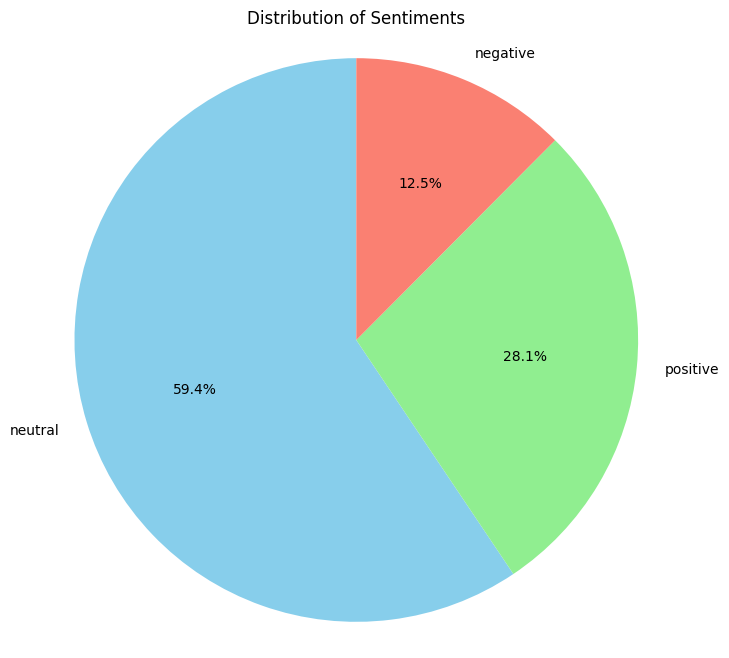

In [20]:
import matplotlib.pyplot as plt

# Calculate the sentiment distribution
sentiment_counts = findata['Sentiment'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'salmon'])
plt.title('Distribution of Sentiments')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### ML modeling without a dictionary

- process data
- model

Process data: 💡 The NLP fundamentals notebook contains a more detailed explanation of text cleaning

In [21]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and numbers
    tokens = word_tokenize(text) # Tokenize
    cleaned_tokens = [word for word in tokens if word not in stop_words] # Remove stopwords
    return ' '.join(cleaned_tokens) # Join tokens back into a string

findata['Cleaned_Sentence'] = findata['Sentence'].apply(clean_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [22]:
display(findata.head(10))

,Sentiment,Sentence,Cleaned_Sentence
0,neutral,"According to Gran , the company has no plans t...",according gran company plans move production r...
1,neutral,Technopolis plans to develop in stages an area...,technopolis plans develop stages area less squ...
2,negative,The international electronic industry company ...,international electronic industry company elco...
3,positive,With the new production plant the company woul...,new production plant company would increase ca...
4,positive,According to the company 's updated strategy f...,according company updated strategy years baswa...
5,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,financing aspocomp growth aspocomp aggressivel...
6,positive,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sales doubled eurm...
7,positive,"In the third quarter of 2010 , net sales incre...",third quarter net sales increased eur mn opera...
8,positive,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose eur mn eur mn correspond...
9,positive,"Operating profit totalled EUR 21.1 mn , up fro...",operating profit totalled eur mn eur mn repres...


We can also lemmatize the sentences

In [23]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4') # Open Multilingual WordNet for broader coverage
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng')


lemmatizer = WordNetLemmatizer()

# Function to get the appropriate WordNet POS tag for lemmatization
def get_wordnet_pos(word):
    """Map POS tag to first character used by WordNetLemmatizer"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    tokens = text.split() # Split the cleaned sentence into tokens
    lemmatized_tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]
    return ' '.join(lemmatized_tokens)

findata['Lemmatized_Sentence'] = findata['Cleaned_Sentence'].apply(lemmatize_text)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [24]:
display(findata.head(10))

,Sentiment,Sentence,Cleaned_Sentence,Lemmatized_Sentence
0,neutral,"According to Gran , the company has no plans t...",according gran company plans move production r...,accord gran company plan move production russi...
1,neutral,Technopolis plans to develop in stages an area...,technopolis plans develop stages area less squ...,technopolis plan develop stage area less squar...
2,negative,The international electronic industry company ...,international electronic industry company elco...,international electronic industry company elco...
3,positive,With the new production plant the company woul...,new production plant company would increase ca...,new production plant company would increase ca...
4,positive,According to the company 's updated strategy f...,according company updated strategy years baswa...,accord company update strategy year basware ta...
5,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,financing aspocomp growth aspocomp aggressivel...,financing aspocomp growth aspocomp aggressivel...
6,positive,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sales doubled eurm...,last quarter componenta net sale double eurm e...
7,positive,"In the third quarter of 2010 , net sales incre...",third quarter net sales increased eur mn opera...,third quarter net sale increase eur mn operati...
8,positive,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose eur mn eur mn correspond...,operating profit rise eur mn eur mn correspond...
9,positive,"Operating profit totalled EUR 21.1 mn , up fro...",operating profit totalled eur mn eur mn repres...,operating profit total eur mn eur mn represent...


<br>
<h3> <b>❓ Do we need to pre-process the text when doing sentiment analysis without a dictionary? Does lemmatization help? How about stemming?
</b>

Train a model

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(findata['Lemmatized_Sentence'], findata['Sentiment'], test_size=0.2, random_state=42)

# Convert text data into numerical features using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limit to top 5000 features
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Train a Logistic Regression model
model = LogisticRegression(max_iter=1000) # Increase max_iter for convergence
model.fit(X_train_tfidf, y_train)

# Evaluate the model
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.82      0.45      0.58       110
     neutral       0.74      0.95      0.83       571
    positive       0.78      0.47      0.59       289

    accuracy                           0.75       970
   macro avg       0.78      0.62      0.67       970
weighted avg       0.76      0.75      0.73       970



💡 **Run the same model using a different sentence or cleaned_sentences as inputs and compare results**

❓  Which version of Sentence would provide the best results?

Train a different model and compare results

In [26]:
# Train a Random Forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Using the same X_train_tfidf, X_test_tfidf, y_train, y_test from the previous cell
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # You can adjust n_estimators
rf_model.fit(X_train_tfidf, y_train)

# Evaluate the Random Forest model
y_pred_rf = rf_model.predict(X_test_tfidf)
print("Classification Report for Random Forest Model:")
print(classification_report(y_test, y_pred_rf))

Classification Report for Random Forest Model:
              precision    recall  f1-score   support

    negative       0.71      0.40      0.51       110
     neutral       0.75      0.95      0.84       571
    positive       0.75      0.48      0.59       289

    accuracy                           0.75       970
   macro avg       0.74      0.61      0.65       970
weighted avg       0.75      0.75      0.73       970



### Using a dictionary or lexicon



Use NLTK's Vader dictionary

In [27]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

# Download the VADER lexicon if not already downloaded
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

# Initialize VADER sentiment intensity analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get VADER sentiment score for a sentence
def vader_sentiment_score(sentence):
    score = analyzer.polarity_scores(sentence)
    # Classify as positive, negative, or neutral based on the compound score
    if score['compound'] >= 0.05:
        return 'positive'
    elif score['compound'] <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply VADER to the original 'Lemmatized_Sentence' column. Compare the model with the other versions of Sentence
findata['Vader_Sentiment'] = findata['Lemmatized_Sentence'].apply(vader_sentiment_score)

# Display the original sentence, actual sentiment, and VADER sentiment
display(findata[['Sentence', 'Sentiment', 'Vader_Sentiment']].head(10))

# You can also evaluate VADER's performance against the actual sentiment
from sklearn.metrics import classification_report

print("\nVADER Sentiment Classification Report:")
print(classification_report(findata['Sentiment'], findata['Vader_Sentiment']))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,Sentence,Sentiment,Vader_Sentiment
0,"According to Gran , the company has no plans t...",neutral,neutral
1,Technopolis plans to develop in stages an area...,neutral,neutral
2,The international electronic industry company ...,negative,neutral
3,With the new production plant the company woul...,positive,positive
4,According to the company 's updated strategy f...,positive,positive
5,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,positive,positive
6,"For the last quarter of 2010 , Componenta 's n...",positive,positive
7,"In the third quarter of 2010 , net sales incre...",positive,positive
8,Operating profit rose to EUR 13.1 mn from EUR ...,positive,positive
9,"Operating profit totalled EUR 21.1 mn , up fro...",positive,positive



VADER Sentiment Classification Report:
              precision    recall  f1-score   support

    negative       0.45      0.31      0.37       604
     neutral       0.74      0.52      0.62      2879
    positive       0.40      0.70      0.51      1363

    accuracy                           0.55      4846
   macro avg       0.53      0.51      0.50      4846
weighted avg       0.61      0.55      0.55      4846



<h3> <b>❓ Compare dictionary vs. machine learning sentiment analysis methods. Which method would you say works best and why?
</b>

AI-generated response:

*For speed and simplicity:* If you need a fast, transparent, and easy-to-implement solution for general text (like social media) and don't have the time or data to train a model, use a lexicon-based approach like NLTK's VADER.

*For accuracy and depth:* If you require the highest possible accuracy for complex or domain-specific text and have the resources to gather and label a large dataset, a machine learning approach is the superior choice.

*For a balanced solution:* A hybrid approach, which combines machine learning with lexicon-based rules, can achieve a better balance of speed, accuracy, and adaptability.

## Try with AI

*Sample prompt:*

Use the best available model to improve the results of the models above to classify sentiment on findata dataset

<h3> ⏰ You  may need to use a GPU runtime to efficiently run the code below </h3>

Use a pre-trained transformer model from HuggingFace to classify the sentiment of the financial news data. This approach often yields better results compared to traditional methods, especially on complex text.


*Follow up prompt: (As results did not improve)*

Please improve results using other models from HuggingFace

The response provides a model that is specifically fine-tuned for financial sentiment analysis, which might improve the results. I will use the "ProsusAI/finbert" model.

In [28]:
!pip install transformers torch

from transformers import pipeline
import pandas as pd
from sklearn.metrics import classification_report
from tqdm.notebook import tqdm # Import tqdm for progress bar

# Load a pre-trained sentiment analysis model specifically fine-tuned for financial text
# "ProsusAI/finbert" is a good option. Note that using a new model might require a runtime restart.
try:
    # Specify the model directly
    sentiment_pipeline = pipeline("sentiment-analysis", model="ProsusAI/finbert")
except Exception as e:
    print(f"Error loading pipeline: {e}")
    print("Please ensure you have installed the transformers and torch libraries and potentially restart the runtime if needed.")
    sentiment_pipeline = None

if sentiment_pipeline:
    # Apply the sentiment analysis pipeline to the 'Sentence' column for the full dataset
    # Process in batches to manage memory and time
    batch_size = 100 # You can adjust the batch size
    all_predicted_sentiments = []

    print(f"Processing {len(findata)} sentences in batches of {batch_size} using ProsusAI/finbert...")
    for i in tqdm(range(0, len(findata), batch_size)):
        batch_sentences = findata['Sentence'].iloc[i : i + batch_size].tolist()
        # The output format might differ between models. FinBERT often outputs scores for POS, NEU, NEG.
        batch_results = sentiment_pipeline(batch_sentences)

        # Extract the predicted sentiment label. FinBERT labels are typically 'positive', 'neutral', 'negative'.
        # Convert to lowercase to match your dataset's labels if necessary.
        # You might need to inspect batch_results structure to extract the correct label.
        # Example: assuming it's a list of dictionaries, each with a 'label' key:
        batch_predicted_sentiments = [result['label'].lower() for result in batch_results]

        all_predicted_sentiments.extend(batch_predicted_sentiments)

    # Add the predicted sentiments to the DataFrame
    findata['Transformer_Sentiment_FinBERT'] = all_predicted_sentiments

    # Display the original sentence, actual sentiment, and the new transformer sentiment for the first few rows
    display(findata[['Sentence', 'Sentiment', 'Transformer_Sentiment_FinBERT']].head())

    # Evaluate performance on the full dataset
    print("\nTransformer Sentiment Classification Report (Full Dataset - FinBERT):")
    # Ensure the predicted labels match the format of your actual labels ('negative', 'neutral', 'positive')
    # You might need to map labels if the model outputs different strings (e.g., 'NEG', 'NEU', 'POS')
    print(classification_report(findata['Sentiment'], findata['Transformer_Sentiment_FinBERT']))

else:
    print("Sentiment pipeline could not be loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

Processing 4846 sentences in batches of 100 using ProsusAI/finbert...


  0%|          | 0/49 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,Sentence,Sentiment,Transformer_Sentiment_FinBERT
0,"According to Gran , the company has no plans t...",neutral,neutral
1,Technopolis plans to develop in stages an area...,neutral,neutral
2,The international electronic industry company ...,negative,negative
3,With the new production plant the company woul...,positive,positive
4,According to the company 's updated strategy f...,positive,positive



Transformer Sentiment Classification Report (Full Dataset - FinBERT):
              precision    recall  f1-score   support

    negative       0.80      0.97      0.88       604
     neutral       0.96      0.86      0.91      2879
    positive       0.81      0.92      0.86      1363

    accuracy                           0.89      4846
   macro avg       0.86      0.92      0.88      4846
weighted avg       0.90      0.89      0.89      4846



## Recap and discussion




We have seen how training general classification models work versus state-of-the-art pre-trained models on financial data

<h3> <b>❓ AI can seemingly solve these tasks efficiently. However, how do we apply and explain away these results in our work? What is the value of learning the concepts and methodologies underpinning these models?
</b>

### Resources

### Kaggle

https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news

https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis

https://www.kaggle.com/datasets/ibrahimqasimi/imdb-50k-cleaned-movie-reviews/code


### HuggingFace

https://srdas.github.io/NLPBook/Hugging_Face.html